In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [ ]:
df_raw = pd.read_csv('data.csv', encoding='ISO-8859-1')
print("Data Loaded ! Shape : ",df_raw.shape)

Data Loaded ! Shape :  (541909, 8)


In [ ]:
print("Shape:", df_raw.shape)
print("Number of rows:", df_raw.shape[0])
print("Number of columns:", df_raw.shape[1])

Shape: (541909, 8)
Number of rows: 541909
Number of columns: 8


In [ ]:
print(df_raw.columns.tolist())
print(df_raw.head())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  




*  InvoiceNo -> orderId
*  StockId -> ProductId








In [ ]:
print("Data types:")
print(df_raw.dtypes)

Data types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


In [ ]:
print("Missing values per column:")
print(df_raw.isnull().sum())
print("\nMissing as percentage:")
print((df_raw.isnull().sum() / len(df_raw) * 100).round(2))

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing as percentage:
InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64


In [ ]:
print("Basic statistics:")
print(df_raw.describe())

Basic statistics:
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000


### Observations from Basic Statistics

- Quantity contains negative values indicating returns
- Extreme values suggest outliers in quantity and price
- UnitPrice has negative values, which are invalid
- CustomerID has missing values (25%)
- Data requires cleaning before analysis

In [ ]:
cancelled = df_raw[df_raw['InvoiceNo'].astype(str).str.startswith('C', na=False)]
print(f"Total cancelled orders (returns): {len(cancelled):,}")
print(f"That is {len(cancelled)/len(df_raw)*100:.1f}% of all transactions")
print(f"Unique customers who returned: {cancelled['CustomerID'].dropna().nunique():,}")
print(f"\nSample of cancelled orders:")
print(cancelled.head())

Total cancelled orders (returns): 9,288
That is 1.7% of all transactions
Unique customers who returned: 1,589

Sample of cancelled orders:
    InvoiceNo StockCode                       Description  Quantity  \
141   C536379         D                          Discount        -1   
154   C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
235   C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12   
236   C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
237   C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   

         InvoiceDate  UnitPrice  CustomerID         Country  
141   12/1/2010 9:41      27.50     14527.0  United Kingdom  
154   12/1/2010 9:49       4.65     15311.0  United Kingdom  
235  12/1/2010 10:24       1.65     17548.0  United Kingdom  
236  12/1/2010 10:24       0.29     17548.0  United Kingdom  
237  12/1/2010 10:24       0.29     17548.0  United Kingdom  


In [ ]:
unique_cancelled_orders = cancelled['InvoiceNo'].nunique()
print("Unique cancelled orders:", unique_cancelled_orders)

Unique cancelled orders: 3836


### Day 1 Summary

- Dataset contains ~541k transactions
- Around 25% CustomerID values are missing
- Returns account for 1.7% of transactions
- 1,589 unique customers are involved in returns
- Returns are identifiable using InvoiceNo starting with 'C' and negative quantities
- Data contains anomalies such as negative prices and extreme values

### Day 2

In [ ]:
import pandas as pd

df_raw = pd.read_csv('data.csv', encoding='ISO-8859-1')
print("Data loaded:", df_raw.shape)

df = df_raw.copy()
print("Working copy created:", df.shape)

Data loaded: (541909, 8)
Working copy created: (541909, 8)


In [ ]:
df_returns = df[df['InvoiceNo'].astype(str).str.startswith('C')].copy()
print("=== RETURNS DATAFRAME ===")
print(f"Total return rows: {len(df_returns):,}")
print(f"Unique customers who returned: {df_returns['CustomerID'].dropna().nunique():,}")
print(f"\nSample of return rows:")
print(df_returns.head(8))
print(f"\nQuantity in returns (should be negative):")
print(df_returns['Quantity'].describe())

=== RETURNS DATAFRAME ===
Total return rows: 9,288
Unique customers who returned: 1,589

Sample of return rows:
    InvoiceNo StockCode                        Description  Quantity  \
141   C536379         D                           Discount        -1   
154   C536383    35004C    SET OF 3 COLOURED  FLYING DUCKS        -1   
235   C536391     22556     PLASTERS IN TIN CIRCUS PARADE        -12   
236   C536391     21984   PACK OF 12 PINK PAISLEY TISSUES        -24   
237   C536391     21983   PACK OF 12 BLUE PAISLEY TISSUES        -24   
238   C536391     21980  PACK OF 12 RED RETROSPOT TISSUES        -24   
239   C536391     21484        CHICK GREY HOT WATER BOTTLE       -12   
240   C536391     22557   PLASTERS IN TIN VINTAGE PAISLEY        -12   

         InvoiceDate  UnitPrice  CustomerID         Country  
141   12/1/2010 9:41      27.50     14527.0  United Kingdom  
154   12/1/2010 9:49       4.65     15311.0  United Kingdom  
235  12/1/2010 10:24       1.65     17548.0  United K

In [ ]:
df_returns = df_returns.dropna(subset=['CustomerID'])
df_returns['CustomerID'] = df_returns['CustomerID'].astype(int)
df_returns['InvoiceDate'] = pd.to_datetime(df_returns['InvoiceDate'])
df_returns['ReturnValue'] = df_returns['Quantity'].abs() * df_returns['UnitPrice']

print("=== CLEANED RETURNS DF ===")
print(f"Shape after cleaning: {df_returns.shape}")
print(f"Unique returning customers: {df_returns['CustomerID'].nunique():,}")
print(f"\nTotal return value in dataset: £{df_returns['ReturnValue'].sum():,.0f}")
print(f"\nSample with ReturnValue column:")
print(df_returns[['CustomerID','InvoiceNo','Quantity','UnitPrice','ReturnValue']].head(8))

=== CLEANED RETURNS DF ===
Shape after cleaning: (8905, 9)
Unique returning customers: 1,589

Total return value in dataset: £611,342

Sample with ReturnValue column:
     CustomerID InvoiceNo  Quantity  UnitPrice  ReturnValue
141       14527   C536379        -1      27.50        27.50
154       15311   C536383        -1       4.65         4.65
235       17548   C536391       -12       1.65        19.80
236       17548   C536391       -24       0.29         6.96
237       17548   C536391       -24       0.29         6.96
238       17548   C536391       -24       0.29         6.96
239       17548   C536391       -12       3.45        41.40
240       17548   C536391       -12       1.65        19.80


In [ ]:
print("=== MAIN DATAFRAME CLEANING ===")
print(f"Starting shape: {df.shape}")
print(f"Starting rows: {len(df):,}")

=== MAIN DATAFRAME CLEANING ===
Starting shape: (541909, 8)
Starting rows: 541,909


In [ ]:
before = len(df)
df = df.dropna(subset=['CustomerID'])
after = len(df)

print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Rows removed: {before - after:,} ({(before-after)/before*100:.1f}% of data)")

Rows before: 541,909
Rows after:  406,829
Rows removed: 135,080 (24.9% of data)


In [ ]:
before = len(df)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
after = len(df)

print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Cancelled rows removed: {before - after:,}")

Rows before: 406,829
Rows after:  397,924
Cancelled rows removed: 8,905


In [ ]:
before = len(df)
df = df[df['Quantity'] > 0]
after = len(df)

print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Bad quantity rows removed: {before - after:,}")
print(f"\nQuantity stats after cleaning:")
print(df['Quantity'].describe())

Rows before: 397,924
Rows after:  397,924
Bad quantity rows removed: 0

Quantity stats after cleaning:
count    397924.000000
mean         13.021823
std         180.420210
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64


In [ ]:
before = len(df)
df = df[df['UnitPrice'] > 0]
after = len(df)

print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Bad price rows removed: {before - after:,}")
print(f"\nUnitPrice stats after cleaning:")
print(df['UnitPrice'].describe())

Rows before: 397,924
Rows after:  397,884
Bad price rows removed: 40

UnitPrice stats after cleaning:
count    397884.000000
mean          3.116488
std          22.097877
min           0.001000
25%           1.250000
50%           1.950000
75%           3.750000
max        8142.750000
Name: UnitPrice, dtype: float64


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("InvoiceDate dtype:", df['InvoiceDate'].dtype)
print("Earliest date:", df['InvoiceDate'].min())
print("Latest date:  ", df['InvoiceDate'].max())
print("Date range:   ", (df['InvoiceDate'].max() - df['InvoiceDate'].min()).days, "days")

InvoiceDate dtype: datetime64[ns]
Earliest date: 2010-12-01 08:26:00
Latest date:   2011-12-09 12:50:00
Date range:    373 days


In [ ]:
df['CustomerID'] = df['CustomerID'].astype(int)

print("CustomerID dtype:", df['CustomerID'].dtype)
print("Sample CustomerIDs:", df['CustomerID'].head(5).tolist())
print(f"Unique customers: {df['CustomerID'].nunique():,}")

CustomerID dtype: int64
Sample CustomerIDs: [17850, 17850, 17850, 17850, 17850]
Unique customers: 4,338


In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("TotalPrice column created")
print(f"\nTotalPrice stats:")
print(df['TotalPrice'].describe().round(2))
print(f"\nTotal revenue in dataset: £{df['TotalPrice'].sum():,.0f}")
print(f"\nSample rows with TotalPrice:")
print(df[['CustomerID','Quantity','UnitPrice','TotalPrice']].head(8))

TotalPrice column created

TotalPrice stats:
count    397884.00
mean         22.40
std         309.07
min           0.00
25%           4.68
50%          11.80
75%          19.80
max      168469.60
Name: TotalPrice, dtype: float64

Total revenue in dataset: £8,911,408

Sample rows with TotalPrice:
   CustomerID  Quantity  UnitPrice  TotalPrice
0       17850         6       2.55       15.30
1       17850         6       3.39       20.34
2       17850         8       2.75       22.00
3       17850         6       3.39       20.34
4       17850         6       3.39       20.34
5       17850         2       7.65       15.30
6       17850         6       4.25       25.50
7       17850         6       1.85       11.10


### Day 3

In [ ]:
import pandas as pd

# Load data
df_raw = pd.read_csv('data.csv', encoding='ISO-8859-1')

# Create working copy
df = df_raw.copy()

# Basic cleaning (minimum required for Day 3)
df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Convert types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)

# Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']


In [ ]:
# Extract returns BEFORE cleaning
df_returns = df_raw[df_raw['InvoiceNo'].astype(str).str.startswith('C')].copy()
df_returns = df_returns.dropna(subset=['CustomerID'])
df_returns['CustomerID'] = df_returns['CustomerID'].astype(int)
df_returns['InvoiceDate'] = pd.to_datetime(df_returns['InvoiceDate'])
df_returns['ReturnValue'] = df_returns['Quantity'].abs() * df_returns['UnitPrice']

# Clean main df
df = df_raw.copy()
df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID']  = df['CustomerID'].astype(int)
df['TotalPrice']  = df['Quantity'] * df['UnitPrice']

print(f"df shape: {df.shape}")
print(f"df_returns shape: {df_returns.shape}")
print("Both dataframes ready for Day 3")

df shape: (397884, 9)
df_returns shape: (8905, 9)
Both dataframes ready for Day 3


In [ ]:
snapshot_date = df['InvoiceDate'].max() + pd.DateOffset(days=1)

print(f"Latest transaction in data: {df['InvoiceDate'].max().date()}")
print(f"Snapshot date: {snapshot_date.date()}")

Latest transaction in data: 2011-12-09
Snapshot date: 2011-12-10


In [ ]:
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print(f"RFM table shape: {rfm.shape}")
print(f"Unique customers: {len(rfm):,}")
print(f"\nRFM table sample:")
print(rfm.head(10))
print(f"\nRFM statistics:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

RFM table shape: (4338, 4)
Unique customers: 4,338

RFM table sample:
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40
5       12352       36          8   2506.04
6       12353      204          1     89.00
7       12354      232          1   1079.40
8       12355      214          1    459.40
9       12356       23          3   2811.43

RFM statistics:
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2054.27
std     100.01       7.70    8989.23
min       1.00       1.00       3.75
25%      18.00       1.00     307.41
50%      51.00       2.00     674.48
75%     142.00       5.00    1661.74
max     374.00     209.00  280206.02


In [ ]:
print("=== RFM SANITY CHECKS ===")

print(f"\nRecency range: {rfm['Recency'].min()} to {rfm['Recency'].max()} days")
print(f"Average Recency: {rfm['Recency'].mean():.0f} days")

print(f"\nFrequency range: {rfm['Frequency'].min()} to {rfm['Frequency'].max()} orders")
print(f"Average Frequency: {rfm['Frequency'].mean():.1f} orders")

print(f"\nMonetary range: £{rfm['Monetary'].min()} to £{rfm['Monetary'].max():,.0f}")
print(f"Average Monetary: £{rfm['Monetary'].mean():,.0f}")

print(f"\nTop 5 customers by Monetary:")
print(rfm.nlargest(5, 'Monetary')[['CustomerID','Recency','Frequency','Monetary']])

print(f"\nTop 5 most frequent buyers:")
print(rfm.nlargest(5, 'Frequency')[['CustomerID','Recency','Frequency','Monetary']])

print(f"\nMost recently active customers:")
print(rfm.nsmallest(5, 'Recency')[['CustomerID','Recency','Frequency','Monetary']])

=== RFM SANITY CHECKS ===

Recency range: 1 to 374 days
Average Recency: 93 days

Frequency range: 1 to 209 orders
Average Frequency: 4.3 orders

Monetary range: £3.75 to £280,206
Average Monetary: £2,054

Top 5 customers by Monetary:
      CustomerID  Recency  Frequency   Monetary
1689       14646        2         73  280206.02
4201       18102        1         60  259657.30
3728       17450        8         46  194550.79
3008       16446        1          2  168472.50
1879       14911        1        201  143825.06

Top 5 most frequent buyers:
      CustomerID  Recency  Frequency   Monetary
326        12748        1        209   33719.73
1879       14911        1        201  143825.06
4010       17841        2        124   40991.57
562        13089        3         97   58825.83
1661       14606        1         93   12156.65

Most recently active customers:
     CustomerID  Recency  Frequency  Monetary
61        12423        1          8   1859.31
71        12433        1          7

In [ ]:
returns_per_cust = df_returns.groupby('CustomerID').agg(
    Num_Returns  = ('InvoiceNo',   'nunique'),
    Return_Value = ('ReturnValue', 'sum')
).reset_index()

returns_per_cust['Return_Value'] = returns_per_cust['Return_Value'].round(2)

print(f"Customers who made at least 1 return: {len(returns_per_cust):,}")
print(f"\nReturn statistics:")
print(returns_per_cust[['Num_Returns','Return_Value']].describe().round(2))
print(f"\nTop 10 customers by return value:")
print(returns_per_cust.nlargest(10,'Return_Value'))

Customers who made at least 1 return: 1,589

Return statistics:
       Num_Returns  Return_Value
count      1589.00       1589.00
mean          2.30        384.73
std           3.03       4888.77
min           1.00          0.42
25%           1.00         13.35
50%           1.00         31.60
75%           2.00         84.10
max          47.00     168469.60

Top 10 customers by return value:
      CustomerID  Num_Returns  Return_Value
1136       16446            1     168469.60
0          12346            1      77183.60
779        15098            2      39267.00
1039       16029           13      30032.23
965        15749            1      22998.40
136        12744            3      12158.90
736        14911           47      11252.44
185        12931            5       8593.15
60         12536            2       8495.01
497        14096           17       8043.88


### Return Behavior Insights

- Most customers return products only once
- Return behavior is highly skewed, with a few customers generating very large return values
- Some customers create high losses through single large returns, while others return frequently
- Return activity significantly impacts true customer profitability

In [ ]:
cust = rfm.merge(returns_per_cust, on='CustomerID', how='left')

cust['Num_Returns']  = cust['Num_Returns'].fillna(0).astype(int)
cust['Return_Value'] = cust['Return_Value'].fillna(0)

print(f"Master customer table shape: {cust.shape}")
print(f"\nCustomers with zero returns: {(cust['Num_Returns']==0).sum():,}")
print(f"Customers with at least 1 return: {(cust['Num_Returns']>0).sum():,}")
print(f"\nSample of master table:")
print(cust.head(10))

Master customer table shape: (4338, 6)

Customers with zero returns: 2,782
Customers with at least 1 return: 1,556

Sample of master table:
   CustomerID  Recency  Frequency  Monetary  Num_Returns  Return_Value
0       12346      326          1  77183.60            1      77183.60
1       12347        2          7   4310.00            0          0.00
2       12348       75          4   1797.24            0          0.00
3       12349       19          1   1757.55            0          0.00
4       12350      310          1    334.40            0          0.00
5       12352       36          8   2506.04            3        960.63
6       12353      204          1     89.00            0          0.00
7       12354      232          1   1079.40            0          0.00
8       12355      214          1    459.40            0          0.00
9       12356       23          3   2811.43            0          0.00


In [ ]:
# How often they return (order based)
cust['Return_Freq_Rate'] = (cust['Num_Returns'] / cust['Frequency']).round(4)

# How much of their spend they return (value based)
cust['Return_Value_Rate'] = (cust['Return_Value'] / cust['Monetary']).round(4)

print("Both return rate columns created")
print(f"\nReturn_Freq_Rate stats:")
print(cust['Return_Freq_Rate'].describe().round(4))
print(f"\nReturn_Value_Rate stats:")
print(cust['Return_Value_Rate'].describe().round(4))

# Compare them side by side
print(f"\nSide by side sample:")
print(cust[['CustomerID','Frequency','Num_Returns','Monetary',
            'Return_Value','Return_Freq_Rate','Return_Value_Rate']].head(10))

Both return rate columns created

Return_Freq_Rate stats:
count    4338.0000
mean        0.1775
std         0.3321
min         0.0000
25%         0.0000
50%         0.0000
75%         0.2500
max         4.0000
Name: Return_Freq_Rate, dtype: float64

Return_Value_Rate stats:
count    4338.0000
mean        0.0397
std         0.8749
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0108
max        57.0507
Name: Return_Value_Rate, dtype: float64

Side by side sample:
   CustomerID  Frequency  Num_Returns  Monetary  Return_Value  \
0       12346          1            1  77183.60      77183.60   
1       12347          7            0   4310.00          0.00   
2       12348          4            0   1797.24          0.00   
3       12349          1            0   1757.55          0.00   
4       12350          1            0    334.40          0.00   
5       12352          8            3   2506.04        960.63   
6       12353          1            0     89.00         

### Day 4

In [ ]:
# ============================================================
# MASTER SETUP CELL — Run this first every time you open Colab
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Load raw data ---
df_raw = pd.read_csv('data.csv', encoding='ISO-8859-1')

# --- Extract returns BEFORE cleaning ---
df_returns = df_raw[df_raw['InvoiceNo'].astype(str).str.startswith('C')].copy()
df_returns = df_returns.dropna(subset=['CustomerID'])
df_returns['CustomerID'] = df_returns['CustomerID'].astype(int)
df_returns['InvoiceDate'] = pd.to_datetime(df_returns['InvoiceDate'])
df_returns['ReturnValue'] = df_returns['Quantity'].abs() * df_returns['UnitPrice']

# --- Clean main df ---
df = df_raw.copy()
df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID']  = df['CustomerID'].astype(int)
df['TotalPrice']  = df['Quantity'] * df['UnitPrice']

# --- Build RFM ---
snapshot_date = df['InvoiceDate'].max() + pd.DateOffset(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()
rfm['Monetary'] = rfm['Monetary'].round(2)

# --- Build returns per customer ---
returns_per_cust = df_returns.groupby('CustomerID').agg(
    Num_Returns  = ('InvoiceNo',   'nunique'),
    Return_Value = ('ReturnValue', 'sum')
).reset_index()
returns_per_cust['Return_Value'] = returns_per_cust['Return_Value'].round(2)

# --- Merge into master customer table ---
cust = rfm.merge(returns_per_cust, on='CustomerID', how='left')
cust['Num_Returns']  = cust['Num_Returns'].fillna(0).astype(int)
cust['Return_Value'] = cust['Return_Value'].fillna(0)

# --- Return rate columns ---
cust['Return_Rate']       = (cust['Num_Returns'] / cust['Frequency']).round(4)
cust['Return_Freq_Rate']  = (cust['Num_Returns'] / cust['Frequency']).round(4)
cust['Return_Value_Rate'] = (cust['Return_Value'] / cust['Monetary']).round(4)

# ============================================================
print("=" * 45)
print("SETUP COMPLETE — All variables ready")
print("=" * 45)
print(f"df shape:         {df.shape}")
print(f"df_returns shape: {df_returns.shape}")
print(f"cust shape:       {cust.shape}")
print(f"Snapshot date:    {snapshot_date.date()}")
print(f"Total customers:  {len(cust):,}")
print(f"Total revenue:    £{cust['Monetary'].sum():,.0f}")
print(f"Total returns:    £{cust['Return_Value'].sum():,.0f}")
print("All variables: df, df_returns, cust, rfm, snapshot_date")
print("=" * 45)

SETUP COMPLETE — All variables ready
df shape:         (397884, 9)
df_returns shape: (8905, 9)
cust shape:       (4338, 9)
Snapshot date:    2011-12-10
Total customers:  4,338
Total revenue:    £8,911,408
Total returns:    £600,931
All variables: df, df_returns, cust, rfm, snapshot_date


In [ ]:
price_per_cust = df.groupby('CustomerID').agg(
    Avg_Unit_Price = ('UnitPrice', 'mean'),
    Max_Unit_Price = ('UnitPrice', 'max'),
    Num_Products   = ('StockCode', 'nunique')
).reset_index()

price_per_cust['Avg_Unit_Price'] = price_per_cust['Avg_Unit_Price'].round(2)
price_per_cust['Max_Unit_Price'] = price_per_cust['Max_Unit_Price'].round(2)

print(f"Price features shape: {price_per_cust.shape}")
print(f"\nPrice statistics:")
print(price_per_cust[['Avg_Unit_Price','Max_Unit_Price','Num_Products']].describe().round(2))
print(f"\nSample:")
print(price_per_cust.head(10))

Price features shape: (4338, 4)

Price statistics:
       Avg_Unit_Price  Max_Unit_Price  Num_Products
count         4338.00         4338.00       4338.00
mean             4.47           26.08         61.50
std             34.21          178.21         85.37
min              0.12            0.17          1.00
25%              2.20            8.25         16.00
50%              2.92           12.75         35.00
75%              3.83           16.95         77.00
max           2033.10         8142.75       1787.00

Sample:
   CustomerID  Avg_Unit_Price  Max_Unit_Price  Num_Products
0       12346            1.04            1.04             1
1       12347            2.64           12.75           103
2       12348            5.76           40.00            22
3       12349            8.29          300.00            73
4       12350            3.84           40.00            17
5       12352           15.93          376.50            59
6       12353            6.07            9.95       

In [ ]:
cust = cust.merge(price_per_cust, on='CustomerID', how='left')

print(f"Master table shape after adding pricing: {cust.shape}")
print(f"New columns added: Avg_Unit_Price, Max_Unit_Price, Num_Products")
print(f"\nAny nulls after merge?")
print(cust[['Avg_Unit_Price','Max_Unit_Price','Num_Products']].isnull().sum())
print(f"\nSample with new columns:")
print(cust[['CustomerID','Monetary','Avg_Unit_Price','Max_Unit_Price','Num_Products']].head(10))

Master table shape after adding pricing: (4338, 12)
New columns added: Avg_Unit_Price, Max_Unit_Price, Num_Products

Any nulls after merge?
Avg_Unit_Price    0
Max_Unit_Price    0
Num_Products      0
dtype: int64

Sample with new columns:
   CustomerID  Monetary  Avg_Unit_Price  Max_Unit_Price  Num_Products
0       12346  77183.60            1.04            1.04             1
1       12347   4310.00            2.64           12.75           103
2       12348   1797.24            5.76           40.00            22
3       12349   1757.55            8.29          300.00            73
4       12350    334.40            3.84           40.00            17
5       12352   2506.04           15.93          376.50            59
6       12353     89.00            6.07            9.95             4
7       12354   1079.40            4.50           16.95            58
8       12355    459.40            4.20           12.75            13
9       12356   2811.43            3.20           18.00      

In [ ]:
cust['Price_Bucket'] = pd.qcut(
    cust['Avg_Unit_Price'],
    q=3,
    labels=['Low', 'Mid', 'High']
)

print("Price_Bucket distribution:")
print(cust['Price_Bucket'].value_counts())
print(f"\nAvg_Unit_Price ranges per bucket:")
print(cust.groupby('Price_Bucket')['Avg_Unit_Price'].agg(['min','max','mean']).round(2))
print(f"\nCustomers per bucket:")
print(cust.groupby('Price_Bucket').agg(
    Customers = ('CustomerID', 'count'),
    Avg_Monetary = ('Monetary', 'mean'),
    Avg_Frequency = ('Frequency', 'mean')
).round(2))

Price_Bucket distribution:
Price_Bucket
Low     1449
Mid     1448
High    1441
Name: count, dtype: int64

Avg_Unit_Price ranges per bucket:
               min      max  mean
Price_Bucket                     
Low           0.12     2.44  1.84
Mid           2.45     3.45  2.93
High          3.46  2033.10  8.65

Customers per bucket:
              Customers  Avg_Monetary  Avg_Frequency
Price_Bucket                                        
Low                1449       1807.53           3.89
Mid                1448       2380.30           4.93
High               1441       1974.76           3.99


In [ ]:
threshold = cust['Avg_Unit_Price'].quantile(0.75)
cust['High_Value_Buyer'] = (cust['Avg_Unit_Price'] >= threshold).astype(int)

print(f"High value buyer threshold: £{threshold:.2f}")
print(f"\nHigh value buyers: {cust['High_Value_Buyer'].sum():,}")
print(f"Regular buyers: {(cust['High_Value_Buyer']==0).sum():,}")
print(f"\nAvg Monetary comparison:")
print(cust.groupby('High_Value_Buyer')['Monetary'].mean().round(2))
print(f"\nAvg Return_Value_Rate comparison:")
print(cust.groupby('High_Value_Buyer')['Return_Value_Rate'].mean().round(4))

High value buyer threshold: £3.83

High value buyers: 1,087
Regular buyers: 3,251

Avg Monetary comparison:
High_Value_Buyer
0    2050.74
1    2064.81
Name: Monetary, dtype: float64

Avg Return_Value_Rate comparison:
High_Value_Buyer
0    0.0211
1    0.0952
Name: Return_Value_Rate, dtype: float64


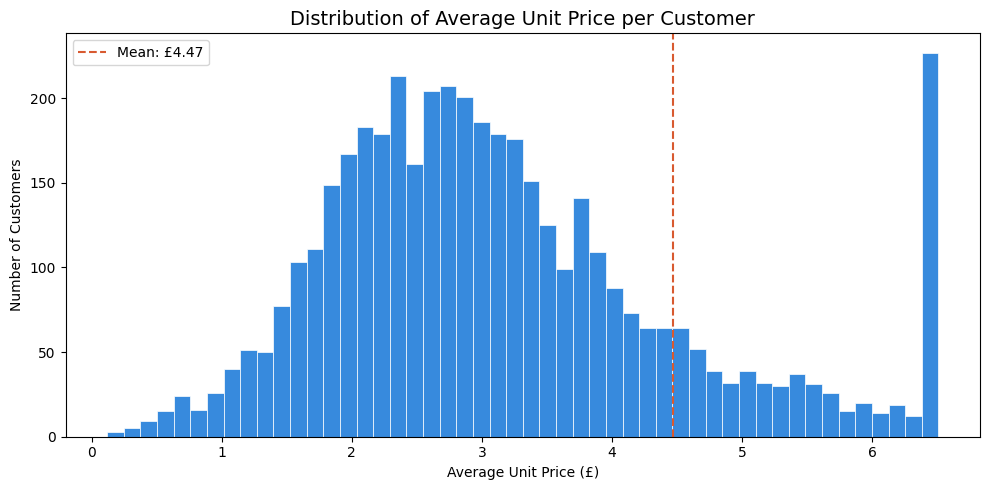

Average unit price across all customers: £4.47
Median unit price: £2.92
95th percentile: £6.51


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

clip_val = cust['Avg_Unit_Price'].quantile(0.95)
ax.hist(cust['Avg_Unit_Price'].clip(upper=clip_val),
        bins=50, color='#378ADD', edgecolor='white', linewidth=0.5)

ax.set_title('Distribution of Average Unit Price per Customer', fontsize=14)
ax.set_xlabel('Average Unit Price (£)')
ax.set_ylabel('Number of Customers')

mean_price = cust['Avg_Unit_Price'].mean()
ax.axvline(mean_price, color='#D85A30', linestyle='--', linewidth=1.5,
           label=f'Mean: £{mean_price:.2f}')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Average unit price across all customers: £{cust['Avg_Unit_Price'].mean():.2f}")
print(f"Median unit price: £{cust['Avg_Unit_Price'].median():.2f}")
print(f"95th percentile: £{cust['Avg_Unit_Price'].quantile(0.95):.2f}")

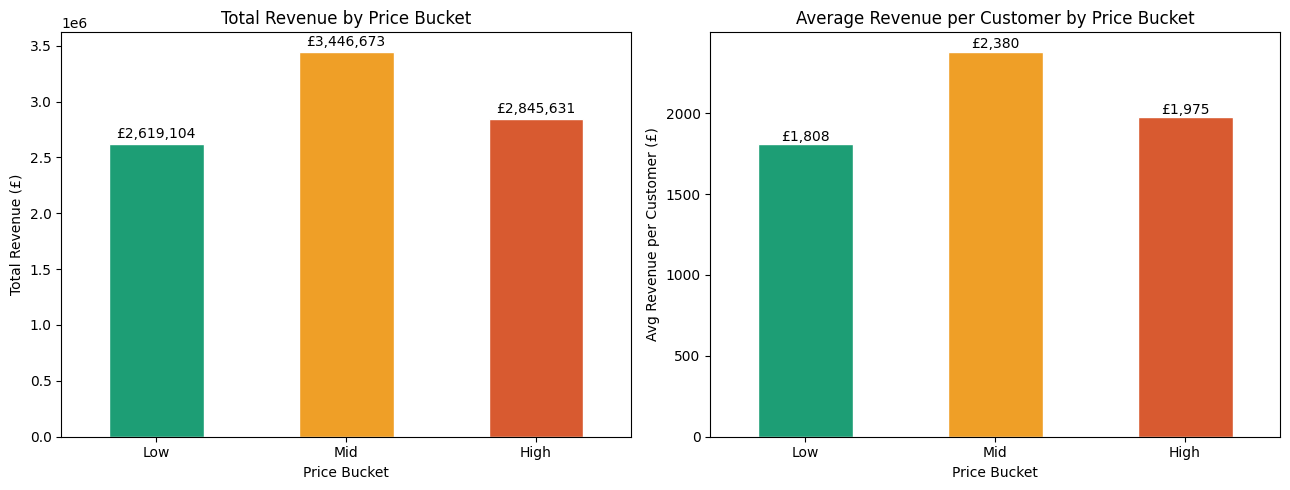

Revenue breakdown by Price Bucket:
              Customers  Total_Rev  Avg_Rev  Avg_Freq
Price_Bucket                                         
Low                1449  2619104.0   1808.0       4.0
Mid                1448  3446673.0   2380.0       5.0
High               1441  2845631.0   1975.0       4.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bucket_total = cust.groupby('Price_Bucket')['Monetary'].sum()
colors = ['#1D9E75', '#EF9F27', '#D85A30']

bucket_total.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Total Revenue by Price Bucket')
axes[0].set_xlabel('Price Bucket')
axes[0].set_ylabel('Total Revenue (£)')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(bucket_total):
    axes[0].text(i, v + 50000, f'£{v:,.0f}', ha='center', fontsize=10)

bucket_avg = cust.groupby('Price_Bucket')['Monetary'].mean()
bucket_avg.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Average Revenue per Customer by Price Bucket')
axes[1].set_xlabel('Price Bucket')
axes[1].set_ylabel('Avg Revenue per Customer (£)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(bucket_avg):
    axes[1].text(i, v + 20, f'£{v:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Revenue breakdown by Price Bucket:")
print(cust.groupby('Price_Bucket').agg(
    Customers    = ('CustomerID', 'count'),
    Total_Rev    = ('Monetary',   'sum'),
    Avg_Rev      = ('Monetary',   'mean'),
    Avg_Freq     = ('Frequency',  'mean')
).round(0))

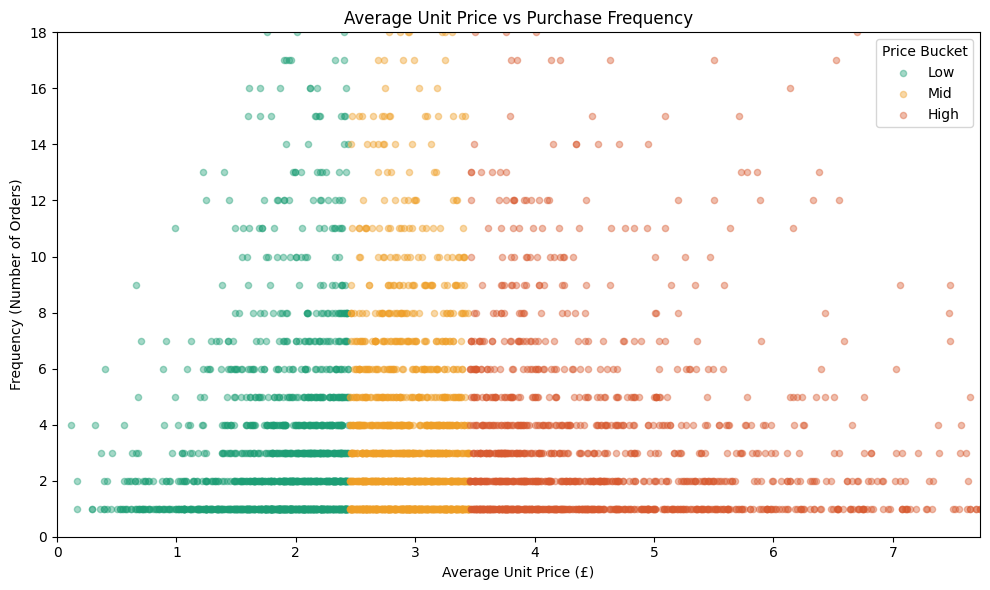

Correlation between Avg_Unit_Price and Frequency: -0.011

Interpretation:
Near zero correlation — price has little relationship with order frequency


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

colors_map = {'Low': '#1D9E75', 'Mid': '#EF9F27', 'High': '#D85A30'}
for bucket, group in cust.groupby('Price_Bucket'):
    ax.scatter(group['Avg_Unit_Price'], group['Frequency'],
               c=colors_map[bucket], label=bucket,
               alpha=0.4, s=20)

ax.set_xlim(0, cust['Avg_Unit_Price'].quantile(0.97))
ax.set_ylim(0, cust['Frequency'].quantile(0.97))
ax.set_title('Average Unit Price vs Purchase Frequency')
ax.set_xlabel('Average Unit Price (£)')
ax.set_ylabel('Frequency (Number of Orders)')
ax.legend(title='Price Bucket')

plt.tight_layout()
plt.show()

corr = cust['Avg_Unit_Price'].corr(cust['Frequency'])
print(f"Correlation between Avg_Unit_Price and Frequency: {corr:.3f}")
print("\nInterpretation:")
if corr < -0.1:
    print("Negative correlation — expensive item buyers tend to order LESS frequently")
elif corr > 0.1:
    print("Positive correlation — expensive item buyers tend to order MORE frequently")
else:
    print("Near zero correlation — price has little relationship with order frequency")

### Day 5

In [ ]:
# =========================================================
# DAY 5 — ADVANCED EDA & VISUAL ANALYTICS
# Rebuilding cleaned master customer dataset
# =========================================================

# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# =========================
# LOAD DATASET
# =========================
df_raw = pd.read_csv('data.csv', encoding='ISO-8859-1')

print("Dataset loaded successfully")
print("Raw shape:", df_raw.shape)

# =========================
# CREATE WORKING COPY
# =========================
df = df_raw.copy()

# =========================================================
# RETURNS DATAFRAME
# =========================================================
df_returns = df[
    df['InvoiceNo'].astype(str).str.startswith('C', na=False)
].copy()

df_returns = df_returns.dropna(subset=['CustomerID'])

df_returns['CustomerID'] = (
    df_returns['CustomerID'].astype(int)
)

df_returns['InvoiceDate'] = pd.to_datetime(
    df_returns['InvoiceDate']
)

df_returns['ReturnValue'] = (
    df_returns['Quantity'].abs() *
    df_returns['UnitPrice']
)

# =========================================================
# CLEAN MAIN DATAFRAME
# =========================================================

# Remove missing customers
df = df.dropna(subset=['CustomerID'])

# Remove cancelled orders
df = df[
    ~df['InvoiceNo'].astype(str).str.startswith('C', na=False)
]

# Remove bad quantities
df = df[df['Quantity'] > 0]

# Remove bad prices
df = df[df['UnitPrice'] > 0]

# Convert data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['CustomerID'] = df['CustomerID'].astype(int)

# Create TotalPrice
df['TotalPrice'] = (
    df['Quantity'] * df['UnitPrice']
)

print("\nClean dataframe shape:", df.shape)

# =========================================================
# CREATE RFM TABLE
# =========================================================
snapshot_date = (
    df['InvoiceDate'].max() +
    pd.DateOffset(days=1)
)

rfm = df.groupby('CustomerID').agg(
    Recency=(
        'InvoiceDate',
        lambda x: (snapshot_date - x.max()).days
    ),

    Frequency=('InvoiceNo', 'nunique'),

    Monetary=('TotalPrice', 'sum')

).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print("\nRFM table shape:", rfm.shape)

# =========================================================
# RETURN FEATURES PER CUSTOMER
# =========================================================
returns_per_cust = df_returns.groupby(
    'CustomerID'
).agg(

    Num_Returns=('InvoiceNo', 'nunique'),

    Return_Value=('ReturnValue', 'sum')

).reset_index()

returns_per_cust['Return_Value'] = (
    returns_per_cust['Return_Value'].round(2)
)

# =========================================================
# MASTER CUSTOMER TABLE
# =========================================================
cust = rfm.merge(
    returns_per_cust,
    on='CustomerID',
    how='left'
)

cust['Num_Returns'] = (
    cust['Num_Returns']
    .fillna(0)
    .astype(int)
)

cust['Return_Value'] = (
    cust['Return_Value']
    .fillna(0)
)

# =========================================================
# RETURN FEATURES
# =========================================================
cust['Return_Freq_Rate'] = (
    cust['Num_Returns'] /
    cust['Frequency']
).round(4)

cust['Return_Value_Rate'] = (
    cust['Return_Value'] /
    cust['Monetary']
).round(4)

# =========================================================
# PRICING FEATURES
# =========================================================
price_per_cust = df.groupby('CustomerID').agg(

    Avg_Unit_Price=('UnitPrice', 'mean'),

    Max_Unit_Price=('UnitPrice', 'max'),

    Num_Products=('StockCode', 'nunique')

).reset_index()

price_per_cust['Avg_Unit_Price'] = (
    price_per_cust['Avg_Unit_Price'].round(2)
)

price_per_cust['Max_Unit_Price'] = (
    price_per_cust['Max_Unit_Price'].round(2)
)

# Merge pricing features
cust = cust.merge(
    price_per_cust,
    on='CustomerID',
    how='left'
)

# =========================================================
# PRICE BUCKETS
# =========================================================
cust['Price_Bucket'] = pd.qcut(
    cust['Avg_Unit_Price'],
    q=3,
    labels=['Low', 'Mid', 'High']
)

# =========================================================
# HIGH VALUE BUYER FEATURE
# =========================================================
threshold = cust['Avg_Unit_Price'].quantile(0.75)

cust['High_Value_Buyer'] = (
    cust['Avg_Unit_Price'] >= threshold
).astype(int)

# =========================================================
# ADJUSTED CLV
# =========================================================
cust['Adjusted_CLV'] = (
    cust['Monetary'] -
    cust['Return_Value']
).round(2)

# =========================================================
# FINAL CHECK
# =========================================================
print("\nMaster customer table ready")
print("Shape:", cust.shape)

print("\nColumns:")
print(cust.columns.tolist())

print("\nSample:")
print(cust.head(5))

Dataset loaded successfully
Raw shape: (541909, 8)

Clean dataframe shape: (397884, 9)

RFM table shape: (4338, 4)

Master customer table ready
Shape: (4338, 14)

Columns:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Num_Returns', 'Return_Value', 'Return_Freq_Rate', 'Return_Value_Rate', 'Avg_Unit_Price', 'Max_Unit_Price', 'Num_Products', 'Price_Bucket', 'High_Value_Buyer', 'Adjusted_CLV']

Sample:
   CustomerID  Recency  Frequency  Monetary  Num_Returns  Return_Value  \
0       12346      326          1  77183.60            1       77183.6   
1       12347        2          7   4310.00            0           0.0   
2       12348       75          4   1797.24            0           0.0   
3       12349       19          1   1757.55            0           0.0   
4       12350      310          1    334.40            0           0.0   

   Return_Freq_Rate  Return_Value_Rate  Avg_Unit_Price  Max_Unit_Price  \
0               1.0                1.0            1.04            1.04   

In [ ]:
print("=" * 50)
print("RETURN BEHAVIOUR OVERVIEW")
print("=" * 50)

print(f"\nTotal customers: {len(cust):,}")
print(f"Customers who never returned: {(cust['Num_Returns']==0).sum():,} ({(cust['Num_Returns']==0).sum()/len(cust)*100:.1f}%)")
print(f"Customers with at least 1 return: {(cust['Num_Returns']>0).sum():,} ({(cust['Num_Returns']>0).sum()/len(cust)*100:.1f}%)")

print(f"\nReturn Value Rate stats (money returned / money spent):")
print(cust['Return_Value_Rate'].describe().round(4))

print(f"\nReturn Freq Rate stats (return orders / total orders):")
print(cust['Return_Freq_Rate'].describe().round(4))

print(f"\nTotal gross revenue: £{cust['Monetary'].sum():,.0f}")
print(f"Total return value: £{cust['Return_Value'].sum():,.0f}")
print(f"Net revenue after returns: £{(cust['Monetary']-cust['Return_Value']).sum():,.0f}")
print(f"Return loss as % of gross: {cust['Return_Value'].sum()/cust['Monetary'].sum()*100:.2f}%")

RETURN BEHAVIOUR OVERVIEW

Total customers: 4,338
Customers who never returned: 2,782 (64.1%)
Customers with at least 1 return: 1,556 (35.9%)

Return Value Rate stats (money returned / money spent):
count    4338.0000
mean        0.0397
std         0.8749
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0108
max        57.0507
Name: Return_Value_Rate, dtype: float64

Return Freq Rate stats (return orders / total orders):
count    4338.0000
mean        0.1775
std         0.3321
min         0.0000
25%         0.0000
50%         0.0000
75%         0.2500
max         4.0000
Name: Return_Freq_Rate, dtype: float64

Total gross revenue: £8,911,408
Total return value: £600,931
Net revenue after returns: £8,310,477
Return loss as % of gross: 6.74%


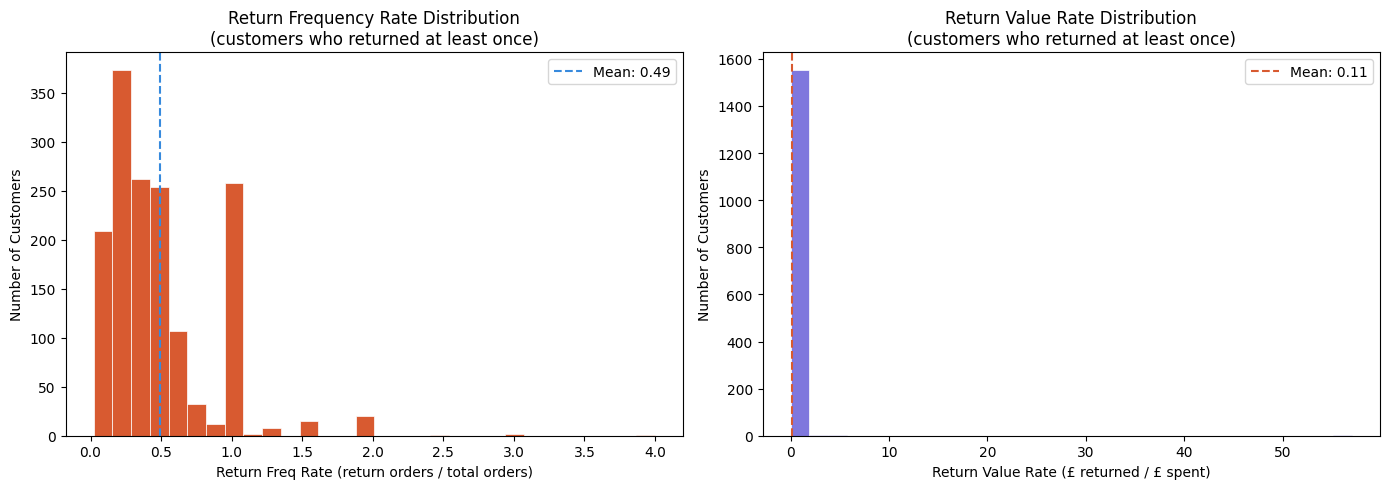

Among customers who returned at least once:
  Avg Return Freq Rate:  0.495
  Avg Return Value Rate: 0.111
  Customers with Return_Value_Rate > 0.5: 39
  Customers with Return_Value_Rate = 1.0: 14


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart — Return Freq Rate distribution
returners = cust[cust['Return_Freq_Rate'] > 0]
axes[0].hist(returners['Return_Freq_Rate'], bins=30,
             color='#D85A30', edgecolor='white', linewidth=0.5)
axes[0].set_title('Return Frequency Rate Distribution\n(customers who returned at least once)')
axes[0].set_xlabel('Return Freq Rate (return orders / total orders)')
axes[0].set_ylabel('Number of Customers')
mean_rfr = returners['Return_Freq_Rate'].mean()
axes[0].axvline(mean_rfr, color='#378ADD', linestyle='--', linewidth=1.5,
                label=f'Mean: {mean_rfr:.2f}')
axes[0].legend()

# Right chart — Return Value Rate distribution
returners2 = cust[cust['Return_Value_Rate'] > 0]
axes[1].hist(returners2['Return_Value_Rate'], bins=30,
             color='#7F77DD', edgecolor='white', linewidth=0.5)
axes[1].set_title('Return Value Rate Distribution\n(customers who returned at least once)')
axes[1].set_xlabel('Return Value Rate (£ returned / £ spent)')
axes[1].set_ylabel('Number of Customers')
mean_rvr = returners2['Return_Value_Rate'].mean()
axes[1].axvline(mean_rvr, color='#D85A30', linestyle='--', linewidth=1.5,
                label=f'Mean: {mean_rvr:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Among customers who returned at least once:")
print(f"  Avg Return Freq Rate:  {returners['Return_Freq_Rate'].mean():.3f}")
print(f"  Avg Return Value Rate: {returners2['Return_Value_Rate'].mean():.3f}")
print(f"  Customers with Return_Value_Rate > 0.5: {(cust['Return_Value_Rate']>0.5).sum():,}")
print(f"  Customers with Return_Value_Rate = 1.0: {(cust['Return_Value_Rate']==1.0).sum():,}")

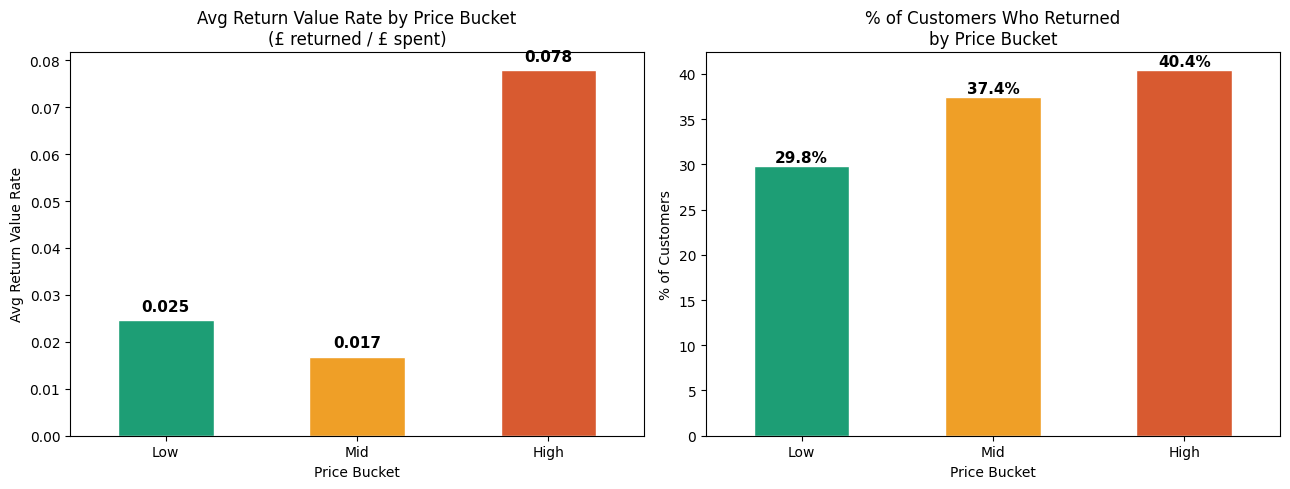


Full breakdown by Price Bucket:
              Customers  Avg_Unit_Price  Pct_Returned  Avg_Return_Value  \
Price_Bucket                                                              
Low                1449            1.84         29.81            213.58   
Mid                1448            2.93         37.43             64.76   
High               1441            8.65         40.39            137.18   

              Avg_RVR  Total_Loss  
Price_Bucket                       
Low              0.02   309484.43  
Mid              0.02    93772.54  
High             0.08   197673.88  


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#1D9E75', '#EF9F27', '#D85A30']

# Left — Avg Return Value Rate by Price Bucket
rvr_by_bucket = cust.groupby('Price_Bucket')['Return_Value_Rate'].mean()
bars1 = rvr_by_bucket.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Avg Return Value Rate by Price Bucket\n(£ returned / £ spent)')
axes[0].set_xlabel('Price Bucket')
axes[0].set_ylabel('Avg Return Value Rate')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(rvr_by_bucket):
    axes[0].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

# Right — % of customers who returned at least once by Price Bucket
return_pct = cust.groupby('Price_Bucket').apply(
    lambda x: (x['Num_Returns'] > 0).sum() / len(x) * 100
)
bars2 = return_pct.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('% of Customers Who Returned\nby Price Bucket')
axes[1].set_xlabel('Price Bucket')
axes[1].set_ylabel('% of Customers')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(return_pct):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nFull breakdown by Price Bucket:")
print(cust.groupby('Price_Bucket').agg(
    Customers        = ('CustomerID',       'count'),
    Avg_Unit_Price   = ('Avg_Unit_Price',   'mean'),
    Pct_Returned     = ('Num_Returns',      lambda x: (x>0).sum()/len(x)*100),
    Avg_Return_Value = ('Return_Value',     'mean'),
    Avg_RVR          = ('Return_Value_Rate','mean'),
    Total_Loss       = ('Return_Value',     'sum')
).round(2))

 High-price buyers exhibit the highest return-value rates, indicating significantly greater financial return risk

 Despite lower return rates, low-price customers generate the highest total return losses due to larger customer volume

 Mid-price customers appear to be the most stable and lowest-risk segment

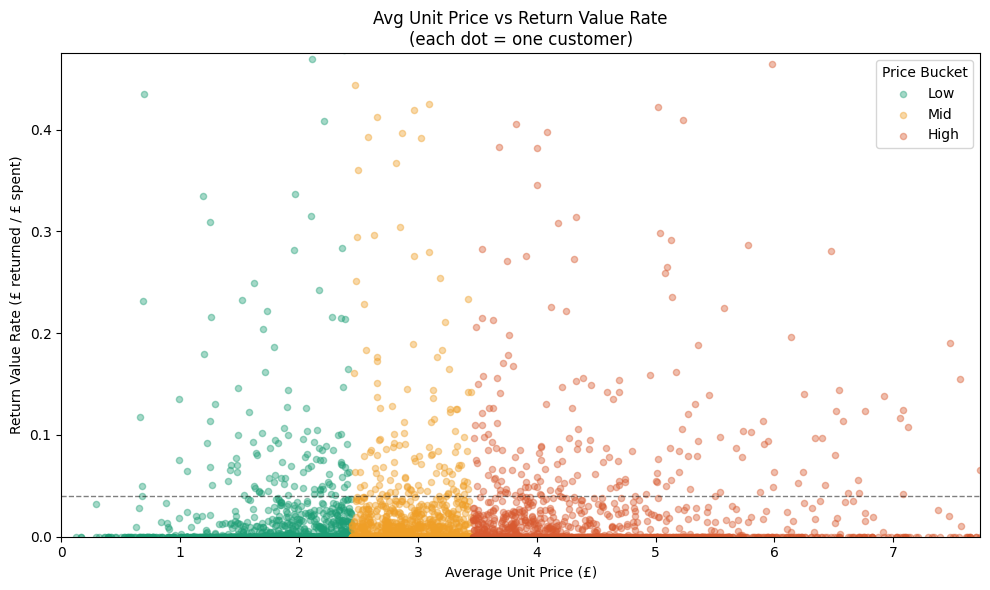

Correlation — Avg Unit Price vs Return Value Rate: 0.019

Finding: Near zero — price has little relationship with return value rate


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

colors_map = {'Low':'#1D9E75', 'Mid':'#EF9F27', 'High':'#D85A30'}
for bucket, group in cust.groupby('Price_Bucket'):
    ax.scatter(group['Avg_Unit_Price'], group['Return_Value_Rate'],
               c=colors_map[bucket], label=bucket,
               alpha=0.4, s=20)

ax.set_xlim(0, cust['Avg_Unit_Price'].quantile(0.97))
ax.set_ylim(0, cust['Return_Value_Rate'].quantile(0.99))
ax.set_title('Avg Unit Price vs Return Value Rate\n(each dot = one customer)')
ax.set_xlabel('Average Unit Price (£)')
ax.set_ylabel('Return Value Rate (£ returned / £ spent)')
ax.legend(title='Price Bucket')
ax.axhline(cust['Return_Value_Rate'].mean(), color='black',
           linestyle='--', linewidth=1, alpha=0.5,
           label=f"Avg: {cust['Return_Value_Rate'].mean():.3f}")

plt.tight_layout()
plt.show()

corr = cust['Avg_Unit_Price'].corr(cust['Return_Value_Rate'])
print(f"Correlation — Avg Unit Price vs Return Value Rate: {corr:.3f}")
print()
if corr > 0.1:
    print("Finding: Positive correlation — expensive item buyers return MORE value proportionally")
elif corr < -0.1:
    print("Finding: Negative correlation — expensive item buyers return LESS value proportionally")
else:
    print("Finding: Near zero — price has little relationship with return value rate")

In [ ]:
print("=" * 55)
print("RETURN LOSS ANALYSIS BY PRICE BUCKET")
print("=" * 55)

loss_analysis = cust.groupby('Price_Bucket').agg(
    Customers      = ('CustomerID',    'count'),
    Gross_Revenue  = ('Monetary',      'sum'),
    Total_Returns  = ('Return_Value',  'sum'),
    Avg_Loss_Per_Customer = ('Return_Value', 'mean')
).round(2)

loss_analysis['Return_Loss_Pct'] = (
    loss_analysis['Total_Returns'] / loss_analysis['Gross_Revenue'] * 100
).round(2)

loss_analysis['Net_Revenue'] = (
    loss_analysis['Gross_Revenue'] - loss_analysis['Total_Returns']
).round(2)

print(loss_analysis.to_string())

print(f"\nTotal gross revenue:  £{cust['Monetary'].sum():,.0f}")
print(f"Total return losses:  £{cust['Return_Value'].sum():,.0f}")
print(f"Total net revenue:    £{(cust['Monetary']-cust['Return_Value']).sum():,.0f}")

print(f"\nWhich bucket loses the most to returns?")
worst_bucket = loss_analysis['Total_Returns'].idxmax()
print(f"Answer: {worst_bucket} bucket — £{loss_analysis.loc[worst_bucket,'Total_Returns']:,.0f} in returns")

RETURN LOSS ANALYSIS BY PRICE BUCKET
              Customers  Gross_Revenue  Total_Returns  Avg_Loss_Per_Customer  Return_Loss_Pct  Net_Revenue
Price_Bucket                                                                                              
Low                1449     2619104.08      309484.43                 213.58            11.82   2309619.65
Mid                1448     3446672.97       93772.54                  64.76             2.72   3352900.43
High               1441     2845630.85      197673.88                 137.18             6.95   2647956.97

Total gross revenue:  £8,911,408
Total return losses:  £600,931
Total net revenue:    £8,310,477

Which bucket loses the most to returns?
Answer: Low bucket — £309,484 in returns


In [ ]:
print("=" * 55)
print("DECEPTIVE CUSTOMERS ANALYSIS")
print("=" * 55)

high_monetary = cust['Monetary'].quantile(0.75)
high_return   = cust['Return_Value_Rate'].quantile(0.75)

deceptive = cust[
    (cust['Monetary'] >= high_monetary) &
    (cust['Return_Value_Rate'] >= high_return)
].copy()

deceptive['True_Value'] = deceptive['Monetary'] - deceptive['Return_Value']

print(f"High Monetary threshold:     £{high_monetary:,.0f} (top 25%)")
print(f"High Return Rate threshold:  {high_return:.3f} (top 25%)")
print(f"\nDeceptive customers found: {len(deceptive):,}")
print(f"Their total gross revenue: £{deceptive['Monetary'].sum():,.0f}")
print(f"Their total return losses: £{deceptive['Return_Value'].sum():,.0f}")
print(f"Their true net value:      £{deceptive['True_Value'].sum():,.0f}")

print(f"\nTop 10 most deceptive customers:")
print(deceptive.nlargest(10, 'Return_Value')[
    ['CustomerID','Monetary','Return_Value','Return_Value_Rate','True_Value','Price_Bucket']
].to_string())

print(f"\nCustomers with True_Value <= 0 (cost more than they earn):")
print(deceptive[deceptive['True_Value'] <= 0][
    ['CustomerID','Monetary','Return_Value','Return_Value_Rate']
].to_string())

DECEPTIVE CUSTOMERS ANALYSIS
High Monetary threshold:     £1,662 (top 25%)
High Return Rate threshold:  0.011 (top 25%)

Deceptive customers found: 439
Their total gross revenue: £3,906,112
Their total return losses: £542,782
Their true net value:      £3,363,330

Top 10 most deceptive customers:
      CustomerID   Monetary  Return_Value  Return_Value_Rate  True_Value Price_Bucket
3008       16446  168472.50     168469.60             1.0000        2.90          Low
0          12346   77183.60      77183.60             1.0000        0.00          Low
2011       15098   39916.50      39267.00             0.9837      649.50         High
2702       16029   81024.84      30032.23             0.3707    50992.61         High
2502       15749   44534.30      22998.40             0.5164    21535.90          Mid
324        12744   21279.29      12158.90             0.5714     9120.39         High
1879       14911  143825.06      11252.44             0.0782   132572.62         High
453        129

In [ ]:
print("=" * 55)
print("HIGH VALUE BUYERS vs REGULAR BUYERS")
print("=" * 55)

comparison = cust.groupby('High_Value_Buyer').agg(
    Customers          = ('CustomerID',       'count'),
    Avg_Unit_Price     = ('Avg_Unit_Price',   'mean'),
    Avg_Monetary       = ('Monetary',         'mean'),
    Pct_Who_Returned   = ('Num_Returns',      lambda x: (x>0).sum()/len(x)*100),
    Avg_Return_Value   = ('Return_Value',     'mean'),
    Avg_RVR            = ('Return_Value_Rate','mean'),
    Total_Return_Loss  = ('Return_Value',     'sum')
).round(2)

comparison.index = ['Regular Buyers', 'High Value Buyers']
print(comparison.to_string())

rvr_regular = cust[cust['High_Value_Buyer']==0]['Return_Value_Rate'].mean()
rvr_hvb     = cust[cust['High_Value_Buyer']==1]['Return_Value_Rate'].mean()
diff = ((rvr_hvb - rvr_regular) / rvr_regular * 100) if rvr_regular > 0 else 0

print(f"\nReturn Value Rate comparison:")
print(f"  Regular buyers:    {rvr_regular:.4f}")
print(f"  High value buyers: {rvr_hvb:.4f}")
print(f"  Difference:        {diff:+.1f}%")

if rvr_hvb > rvr_regular:
    print(f"\nFinding: High value buyers return {diff:.1f}% MORE value proportionally than regular buyers")
else:
    print(f"\nFinding: High value buyers actually return LESS proportionally than regular buyers")

HIGH VALUE BUYERS vs REGULAR BUYERS
                   Customers  Avg_Unit_Price  Avg_Monetary  Pct_Who_Returned  Avg_Return_Value  Avg_RVR  Total_Return_Loss
Regular Buyers          3251            2.52       2050.74             34.88            127.58     0.02          414758.33
High Value Buyers       1087           10.28       2064.81             38.82            171.27     0.10          186172.52

Return Value Rate comparison:
  Regular buyers:    0.0211
  High value buyers: 0.0952
  Difference:        +350.6%

Finding: High value buyers return 350.6% MORE value proportionally than regular buyers


### Day 6

In [ ]:
print("Customers with negative Adjusted_CLV:")
print(cust[cust['Adjusted_CLV'] < 0][
    ['CustomerID','Monetary','Return_Value','Adjusted_CLV','Frequency','Num_Returns']
].to_string())

# Fix — clip to zero (cannot have negative true value)
cust['Adjusted_CLV'] = cust['Adjusted_CLV'].clip(lower=0)

print(f"\nAfter fix:")
print(f"Negative values remaining: {(cust['Adjusted_CLV']<0).sum()}")
print(f"Zero values: {(cust['Adjusted_CLV']==0).sum()}")
print(f"Min Adjusted_CLV: £{cust['Adjusted_CLV'].min():.2f}")

Customers with negative Adjusted_CLV:
      CustomerID  Monetary  Return_Value  Adjusted_CLV  Frequency  Num_Returns
983        13672    186.39        257.85        -71.46          2            4
1531       14437     63.00        106.40        -43.40          1            1
2540       15802    451.42        902.84       -451.42          1            2
2558       15823     15.00        855.76       -840.76          1            1
3014       16454      6.90         15.05         -8.15          2            1
3078       16546    787.15        883.08        -95.93          2            1
3798       17548    103.30        244.78       -141.48          1            2
3839       17603    394.72       1560.02      -1165.30          1            4

After fix:
Negative values remaining: 0
Zero values: 21
Min Adjusted_CLV: £0.00


In [ ]:
# Gross CLV — rewards both frequency and monetary
cust['CLV_Gross'] = cust['Frequency'] * cust['Monetary']

# True CLV — frequency weighted but uses adjusted monetary
cust['CLV_True'] = cust['Frequency'] * cust['Adjusted_CLV']

# Return Loss — how much CLV was lost to returns
cust['Return_Loss'] = cust['CLV_Gross'] - cust['CLV_True']

print("CLV columns created:")
print(cust[['CustomerID','Frequency','Monetary','Adjusted_CLV',
            'CLV_Gross','CLV_True','Return_Loss']].head(10).to_string())

print(f"\nCLV_Gross stats:")
print(cust['CLV_Gross'].describe().round(2))

print(f"\nCLV_True stats:")
print(cust['CLV_True'].describe().round(2))

print(f"\nTotal Return_Loss across all customers: £{cust['Return_Loss'].sum():,.0f}")
print(f"Customers where Return_Loss > 0: {(cust['Return_Loss']>0).sum():,}")

CLV columns created:
   CustomerID  Frequency  Monetary  Adjusted_CLV  CLV_Gross  CLV_True  Return_Loss
0       12346          1  77183.60          0.00   77183.60      0.00     77183.60
1       12347          7   4310.00       4310.00   30170.00  30170.00         0.00
2       12348          4   1797.24       1797.24    7188.96   7188.96         0.00
3       12349          1   1757.55       1757.55    1757.55   1757.55         0.00
4       12350          1    334.40        334.40     334.40    334.40         0.00
5       12352          8   2506.04       1545.41   20048.32  12363.28      7685.04
6       12353          1     89.00         89.00      89.00     89.00         0.00
7       12354          1   1079.40       1079.40    1079.40   1079.40         0.00
8       12355          1    459.40        459.40     459.40    459.40         0.00
9       12356          3   2811.43       2811.43    8434.29   8434.29         0.00

CLV_Gross stats:
count        4338.00
mean        47079.09
std   

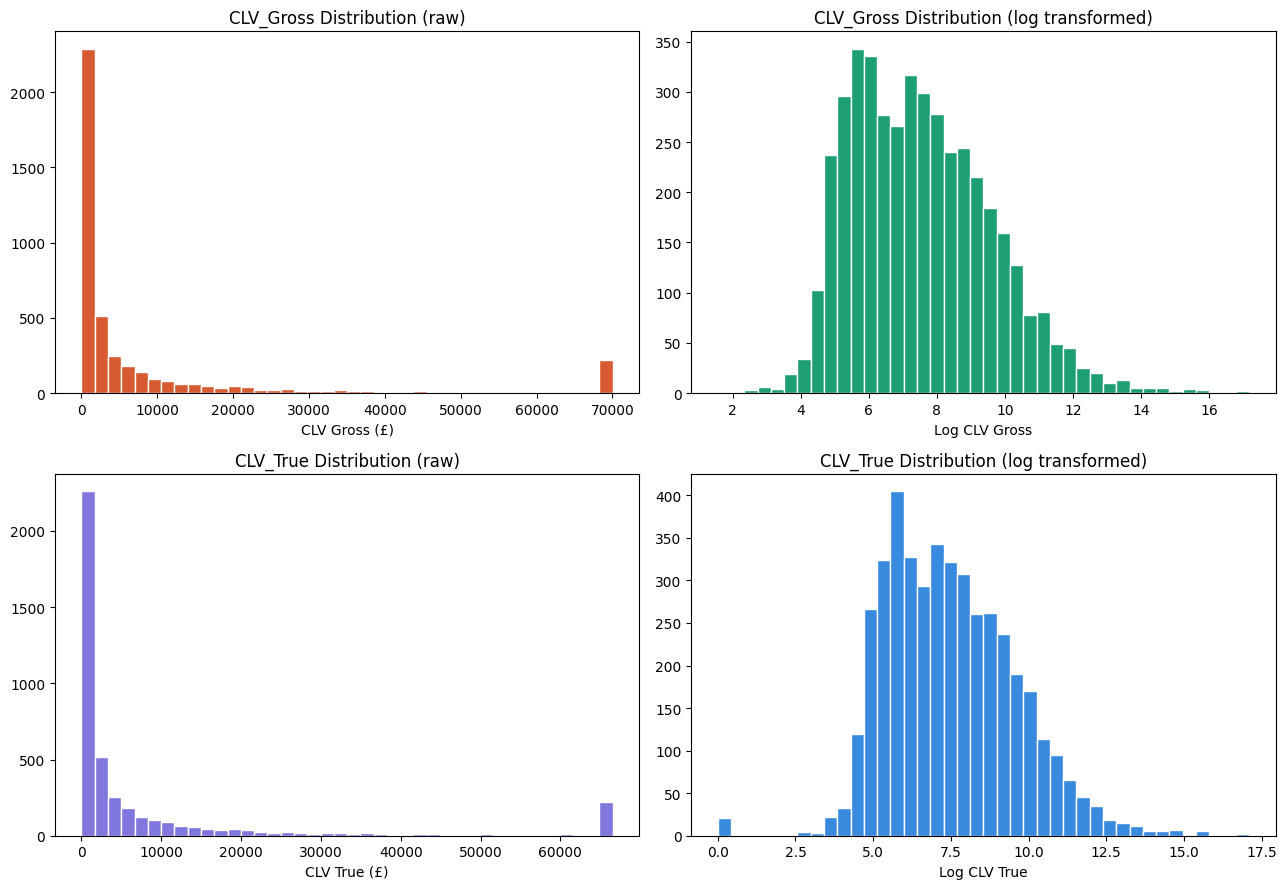

Log transformation complete
Log_CLV_True range: 0.00 to 17.10
Log_CLV_Gross range: 1.56 to 17.18


In [ ]:
import numpy as np

cust['Log_CLV_Gross'] = np.log1p(cust['CLV_Gross'])
cust['Log_CLV_True']  = np.log1p(cust['CLV_True'])

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].hist(cust['CLV_Gross'].clip(upper=cust['CLV_Gross'].quantile(0.95)),
               bins=40, color='#D85A30', edgecolor='white')
axes[0,0].set_title('CLV_Gross Distribution (raw)')
axes[0,0].set_xlabel('CLV Gross (£)')

axes[0,1].hist(cust['Log_CLV_Gross'], bins=40,
               color='#1D9E75', edgecolor='white')
axes[0,1].set_title('CLV_Gross Distribution (log transformed)')
axes[0,1].set_xlabel('Log CLV Gross')

axes[1,0].hist(cust['CLV_True'].clip(upper=cust['CLV_True'].quantile(0.95)),
               bins=40, color='#7F77DD', edgecolor='white')
axes[1,0].set_title('CLV_True Distribution (raw)')
axes[1,0].set_xlabel('CLV True (£)')

axes[1,1].hist(cust['Log_CLV_True'], bins=40,
               color='#378ADD', edgecolor='white')
axes[1,1].set_title('CLV_True Distribution (log transformed)')
axes[1,1].set_xlabel('Log CLV True')

plt.tight_layout()
plt.show()

print("Log transformation complete")
print(f"Log_CLV_True range: {cust['Log_CLV_True'].min():.2f} to {cust['Log_CLV_True'].max():.2f}")
print(f"Log_CLV_Gross range: {cust['Log_CLV_Gross'].min():.2f} to {cust['Log_CLV_Gross'].max():.2f}")

In [ ]:
cust['R_Score'] = pd.qcut(cust['Recency'],
                           5, labels=[5,4,3,2,1]).astype(int)

cust['F_Score'] = pd.qcut(cust['Frequency'].rank(method='first'),
                           5, labels=[1,2,3,4,5]).astype(int)

cust['M_Score'] = pd.qcut(cust['Monetary'],
                           5, labels=[1,2,3,4,5]).astype(int)

cust['RFM_Score'] = cust['R_Score'] + cust['F_Score'] + cust['M_Score']

print("RFM scores created")
print(f"\nR_Score distribution:")
print(cust['R_Score'].value_counts().sort_index())
print(f"\nF_Score distribution:")
print(cust['F_Score'].value_counts().sort_index())
print(f"\nM_Score distribution:")
print(cust['M_Score'].value_counts().sort_index())
print(f"\nRFM_Score range: {cust['RFM_Score'].min()} to {cust['RFM_Score'].max()}")
print(f"RFM_Score mean: {cust['RFM_Score'].mean():.1f}")

RFM scores created

R_Score distribution:
R_Score
1    865
2    843
3    858
4    904
5    868
Name: count, dtype: int64

F_Score distribution:
F_Score
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64

M_Score distribution:
M_Score
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64

RFM_Score range: 3 to 15
RFM_Score mean: 9.0


In [ ]:
# Average order value — how much per shopping trip
cust['Avg_Order_Value'] = (cust['Monetary'] / cust['Frequency']).round(2)

# Revenue per day — how much revenue per day since first purchase
# Using Recency as proxy for customer age (longer ago = older customer)
cust['Revenue_Per_Day'] = (cust['Monetary'] / (366 - cust['Recency'])).round(4)
cust['Revenue_Per_Day'] = cust['Revenue_Per_Day'].clip(lower=0)

# Return damage score — combines frequency and value of returns
cust['Return_Damage'] = (
    cust['Return_Freq_Rate'] * 0.4 +
    cust['Return_Value_Rate'] * 0.6
).round(4)

print("Additional features created:")
print(f"\nAvg_Order_Value stats:")
print(cust['Avg_Order_Value'].describe().round(2))
print(f"\nReturn_Damage stats:")
print(cust['Return_Damage'].describe().round(4))
print(f"\nSample of new features:")
print(cust[['CustomerID','Avg_Order_Value','Revenue_Per_Day',
            'Return_Damage']].head(10).to_string())

Additional features created:

Avg_Order_Value stats:
count     4338.00
mean       419.17
std       1796.54
min          3.45
25%        178.62
50%        293.90
75%        430.11
max      84236.25
Name: Avg_Order_Value, dtype: float64

Return_Damage stats:
count    4338.0000
mean        0.0948
std         0.5544
min         0.0000
25%         0.0000
50%         0.0000
75%         0.1107
max        34.6304
Name: Return_Damage, dtype: float64

Sample of new features:
   CustomerID  Avg_Order_Value  Revenue_Per_Day  Return_Damage
0       12346         77183.60        1929.5900           1.00
1       12347           615.71          11.8407           0.00
2       12348           449.31           6.1761           0.00
3       12349          1757.55           5.0650           0.00
4       12350           334.40           5.9714           0.00
5       12352           313.26           7.5941           0.38
6       12353            89.00           0.5494           0.00
7       12354          107

In [ ]:
print("=" * 55)
print("DAY 6 COMPLETE — FINAL FEATURE TABLE")
print("=" * 55)

print(f"\nShape: {cust.shape}")
print(f"\nAll columns and their types:")
for col in cust.columns:
    nulls = cust[col].isnull().sum()
    null_flag = "⚠️ HAS NULLS" if nulls > 0 else "✓"
    print(f"  {col:25} | {str(cust[col].dtype):10} | {null_flag}")

print(f"\nML Features (X) for Day 8:")
ml_features = ['Recency','Frequency','Monetary','Avg_Order_Value',
               'R_Score','F_Score','M_Score',
               'Return_Freq_Rate','Return_Value_Rate','Return_Damage',
               'Num_Returns','Avg_Unit_Price','High_Value_Buyer','Num_Products']
for f in ml_features:
    if f in cust.columns:
        print(f"  ✓ {f}")
    else:
        print(f"  ✗ {f} MISSING")

print(f"\nML Targets (y) for Day 8:")
print(f"  ✓ Log_CLV_True  (primary — what XGBoost will predict)")
print(f"  ✓ Log_CLV_Gross (secondary — for comparison)")

print(f"\nKey business numbers:")
print(f"  Total customers:       {len(cust):,}")
print(f"  Total gross CLV:       £{cust['CLV_Gross'].sum():,.0f}")
print(f"  Total true CLV:        £{cust['CLV_True'].sum():,.0f}")
print(f"  Total return loss:     £{cust['Return_Loss'].sum():,.0f}")
print(f"  Return loss % of CLV:  {cust['Return_Loss'].sum()/cust['CLV_Gross'].sum()*100:.1f}%")

DAY 6 COMPLETE — FINAL FEATURE TABLE

Shape: (4338, 26)

All columns and their types:
  CustomerID                | int64      | ✓
  Recency                   | int64      | ✓
  Frequency                 | int64      | ✓
  Monetary                  | float64    | ✓
  Num_Returns               | int64      | ✓
  Return_Value              | float64    | ✓
  Return_Freq_Rate          | float64    | ✓
  Return_Value_Rate         | float64    | ✓
  Avg_Unit_Price            | float64    | ✓
  Max_Unit_Price            | float64    | ✓
  Num_Products              | int64      | ✓
  Price_Bucket              | category   | ✓
  High_Value_Buyer          | int64      | ✓
  Adjusted_CLV              | float64    | ✓
  CLV_Gross                 | float64    | ✓
  CLV_True                  | float64    | ✓
  Return_Loss               | float64    | ✓
  Log_CLV_Gross             | float64    | ✓
  Log_CLV_True              | float64    | ✓
  R_Score                   | int64      | ✓
  F_Score     

### Day 7

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import warnings

warnings.filterwarnings('ignore')

cluster_features = [
    'Recency',
    'Frequency',
    'Monetary',
    'Avg_Order_Value',
    'Return_Damage',
    'Avg_Unit_Price',
    'Revenue_Per_Day',
    'CLV_True',
    'Return_Value_Rate'
]

X_cluster = cust[cluster_features].copy()

X_cluster = X_cluster.replace([np.inf, -np.inf], np.nan)

X_cluster = X_cluster.fillna(0)

print("Infinity values remaining:")
print(np.isinf(X_cluster).sum())

print("\nNull values remaining:")
print(X_cluster.isnull().sum())

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)


print("\nFeatures selected for clustering:")

for f in cluster_features:
    print(f"  {f:25} | mean: {cust[f].mean():.2f} | std: {cust[f].std():.2f}")

print(f"\nScaled array shape: {X_scaled.shape}")

print("\nScaling complete — all features normalized successfully")
print("Dataset is now ready for KMeans clustering")

Infinity values remaining:
Recency              0
Frequency            0
Monetary             0
Avg_Order_Value      0
Return_Damage        0
Avg_Unit_Price       0
Revenue_Per_Day      0
CLV_True             0
Return_Value_Rate    0
dtype: int64

Null values remaining:
Recency              0
Frequency            0
Monetary             0
Avg_Order_Value      0
Return_Damage        0
Avg_Unit_Price       0
Revenue_Per_Day      0
CLV_True             0
Return_Value_Rate    0
dtype: int64

Features selected for clustering:
  Recency                   | mean: 92.54 | std: 100.01
  Frequency                 | mean: 4.27 | std: 7.70
  Monetary                  | mean: 2054.27 | std: 8989.23
  Avg_Order_Value           | mean: 419.17 | std: 1796.54
  Return_Damage             | mean: 0.09 | std: 0.55
  Avg_Unit_Price            | mean: 4.47 | std: 34.21
  Revenue_Per_Day           | mean: inf | std: nan
  CLV_True                  | mean: 44799.38 | std: 621868.15
  Return_Value_Rate         

K=2 | Inertia: 30,217 | Silhouette: 0.963
K=3 | Inertia: 22,077 | Silhouette: 0.963
K=4 | Inertia: 17,880 | Silhouette: 0.960
K=5 | Inertia: 14,244 | Silhouette: 0.514
K=6 | Inertia: 10,730 | Silhouette: 0.511
K=7 | Inertia: 7,981 | Silhouette: 0.534
K=8 | Inertia: 6,816 | Silhouette: 0.530
K=9 | Inertia: 6,120 | Silhouette: 0.530
K=10 | Inertia: 5,370 | Silhouette: 0.532


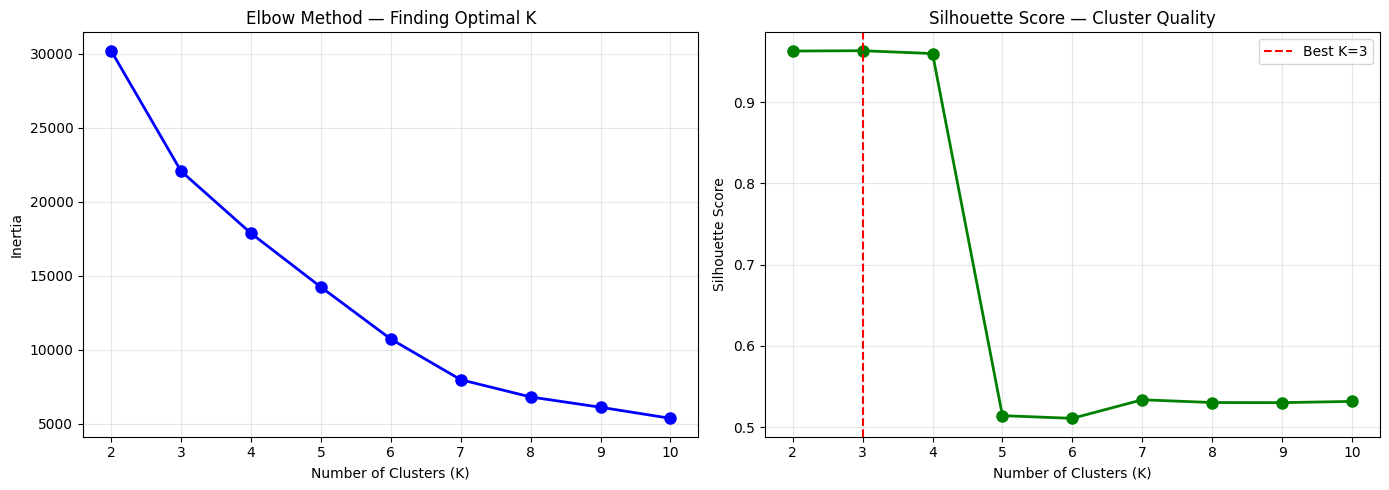


Best K by Silhouette Score: 3
Best Silhouette Score:      0.963

All Silhouette Scores:
  K=2: 0.963
  K=3: 0.963 ← BEST
  K=4: 0.960
  K=5: 0.514
  K=6: 0.511
  K=7: 0.534
  K=8: 0.530
  K=9: 0.530
  K=10: 0.532


In [ ]:
inertias   = []
sil_scores = []
k_range    = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))
    print(f"K={k} | Inertia: {km.inertia_:,.0f} | Silhouette: {silhouette_score(X_scaled, km.labels_):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Finding Optimal K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), sil_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score — Cluster Quality')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
best_k = k_range[sil_scores.index(max(sil_scores))]
axes[1].axvline(best_k, color='red', linestyle='--',
                label=f'Best K={best_k}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest K by Silhouette Score: {best_k}")
print(f"Best Silhouette Score:      {max(sil_scores):.3f}")
print(f"\nAll Silhouette Scores:")
for k, s in zip(k_range, sil_scores):
    marker = " ← BEST" if k == best_k else ""
    print(f"  K={k}: {s:.3f}{marker}")

In [ ]:
FINAL_K  = 3

km_final        = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
cust['Cluster'] = km_final.fit_predict(X_scaled)

print(f"KMeans trained with K={FINAL_K}")

print(f"\nCustomers per cluster:")
print(cust['Cluster'].value_counts().sort_index())

print(f"\nCluster profiles — average values per feature:")
cluster_profile = cust.groupby('Cluster')[cluster_features].mean().round(2)
print(cluster_profile.to_string())

print(f"\nCluster profiles — business metrics:")
print(cust.groupby('Cluster').agg(
    Customers     = ('CustomerID',        'count'),
    Avg_Recency   = ('Recency',           'mean'),
    Avg_Frequency = ('Frequency',         'mean'),
    Avg_Monetary  = ('Monetary',          'mean'),
    Avg_CLV_True  = ('CLV_True',          'mean'),
    Avg_ReturnDmg = ('Return_Damage',     'mean'),
    Avg_UnitPrice = ('Avg_Unit_Price',    'mean'),
    Avg_RVR       = ('Return_Value_Rate', 'mean'),
    Total_Revenue = ('Monetary',          'sum'),
    Total_Loss    = ('Return_Loss',       'sum')
).round(2).to_string())

KMeans trained with K=3

Customers per cluster:
Cluster
0    4331
1       1
2       6
Name: count, dtype: int64

Cluster profiles — average values per feature:
         Recency  Frequency   Monetary  Avg_Order_Value  Return_Damage  Avg_Unit_Price  Revenue_Per_Day     CLV_True  Return_Value_Rate
Cluster                                                                                                                                
0          92.52       4.19    1798.08           379.54           0.09            4.47              inf     28464.42               0.03
1         372.00       1.00      15.00            15.00          34.63           15.00             0.00         0.00              57.05
2          56.50      63.83  187315.88         29088.47           0.35            2.95           801.64  11843381.68               0.35

Cluster profiles — business metrics:
         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Avg_CLV_True  Avg_ReturnDmg  Avg_UnitPrice  Avg_RVR  Total_R

In [ ]:


# ---- Identify outlier thresholds ----
monetary_cap   = cust['Monetary'].quantile(0.99)
clv_cap        = cust['CLV_True'].quantile(0.99)
return_dmg_cap = cust['Return_Damage'].quantile(0.99)

print(f"Monetary 99th percentile:      £{monetary_cap:,.0f}")
print(f"CLV_True 99th percentile:      £{clv_cap:,.0f}")
print(f"Return_Damage 99th percentile: {return_dmg_cap:.3f}")

# ---- Separate outliers from normal customers ----
mask_normal = (
    (cust['Monetary']      <= monetary_cap) &
    (cust['CLV_True']      <= clv_cap) &
    (cust['Return_Damage'] <= return_dmg_cap)
)

cust_normal   = cust[mask_normal].copy()
cust_outliers = cust[~mask_normal].copy()

print(f"\nNormal customers:  {len(cust_normal):,}")
print(f"Outlier customers: {len(cust_outliers):,}")

print(f"\nOutlier customers:")
print(cust_outliers[['CustomerID','Monetary','CLV_True',
                      'Return_Damage','Return_Value_Rate']].to_string())

# ---- Rebuild and scale features on normal customers only ----
X_cluster_normal = cust_normal[cluster_features].copy()
X_cluster_normal = X_cluster_normal.replace([np.inf, -np.inf], np.nan)
X_cluster_normal = X_cluster_normal.fillna(0)

scaler_normal   = StandardScaler()
X_scaled_normal = scaler_normal.fit_transform(X_cluster_normal)

print(f"\nNormal customer array shape: {X_scaled_normal.shape}")
print("Scaling complete")

# ---- Re-run elbow method on normal customers ----
print("\nFinding best K for normal customers:")
inertias_n   = []
sil_scores_n = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_normal)
    inertias_n.append(km.inertia_)
    sil_scores_n.append(silhouette_score(X_scaled_normal, km.labels_))
    print(f"  K={k} | Inertia: {km.inertia_:,.0f} | Silhouette: {silhouette_score(X_scaled_normal, km.labels_):.3f}")

best_k_normal = list(range(2,9))[sil_scores_n.index(max(sil_scores_n))]
print(f"\nBest K: {best_k_normal}")
print(f"Best Silhouette Score: {max(sil_scores_n):.3f}")

# ---- Train final KMeans on normal customers ----
km_normal              = KMeans(n_clusters=best_k_normal, random_state=42, n_init=10)
cust_normal['Cluster'] = km_normal.fit_predict(X_scaled_normal)

print(f"\nCustomers per cluster:")
print(cust_normal['Cluster'].value_counts().sort_index())

print(f"\nCluster business profiles:")
print(cust_normal.groupby('Cluster').agg(
    Customers     = ('CustomerID',        'count'),
    Avg_Recency   = ('Recency',           'mean'),
    Avg_Frequency = ('Frequency',         'mean'),
    Avg_Monetary  = ('Monetary',          'mean'),
    Avg_CLV_True  = ('CLV_True',          'mean'),
    Avg_ReturnDmg = ('Return_Damage',     'mean'),
    Avg_UnitPrice = ('Avg_Unit_Price',    'mean'),
    Avg_RVR       = ('Return_Value_Rate', 'mean'),
    Total_Revenue = ('Monetary',          'sum'),
    Total_Loss    = ('Return_Loss',       'sum')
).round(2).to_string())

Monetary 99th percentile:      £19,881
CLV_True 99th percentile:      £475,936
Return_Damage 99th percentile: 0.821

Normal customers:  4,242
Outlier customers: 96

Outlier customers:
      CustomerID   Monetary     CLV_True  Return_Damage  Return_Value_Rate
0          12346   77183.60         0.00         1.0000             1.0000
55         12415  124914.53   2598234.45         0.1009             0.0095
89         12454    3528.34         0.00         1.0000             1.0000
100        12471   19824.05    562227.60         0.2861             0.0546
108        12479     527.20       477.30         0.8568             0.0947
125        12504     482.05       228.00         0.8581             0.7635
168        12558     269.96         0.00         1.0000             1.0000
185        12579     440.42       410.72         0.8404             0.0674
210        12607    1579.51         0.00         1.0000             1.0000
324        12744   21279.29     63842.73         0.5143           

In [ ]:
# =========================================================
# STEP 4 — NAME CLUSTERS AND MERGE BACK
# =========================================================

# ---- Name the two main clusters ----
cluster_names = {
    0: 'Regular Buyers',
    1: 'Champion Buyers'
}

cust_normal['Persona'] = cust_normal['Cluster'].map(cluster_names)

# ---- Assign outlier personas ----
# Two types of outliers based on their Return_Damage
def assign_outlier_persona(row):
    if row['Return_Damage'] >= 1.0:
        return 'Extreme Returner'
    else:
        return 'Whale Buyer'

cust_outliers['Persona']  = cust_outliers.apply(assign_outlier_persona, axis=1)
cust_outliers['Cluster']  = -1

# ---- Merge normal and outliers back into one table ----
cust = pd.concat([cust_normal, cust_outliers], ignore_index=True)
cust = cust.sort_values('CustomerID').reset_index(drop=True)

print("=" * 55)
print("FINAL PERSONA DISTRIBUTION")
print("=" * 55)
print(f"\nTotal customers: {len(cust):,}")
print(f"\nPersona counts:")
print(cust['Persona'].value_counts())
print(f"\nPersona as % of customers:")
print((cust['Persona'].value_counts() / len(cust) * 100).round(1))

print(f"\nFull persona business profiles:")
print(cust.groupby('Persona').agg(
    Customers     = ('CustomerID',        'count'),
    Avg_Recency   = ('Recency',           'mean'),
    Avg_Frequency = ('Frequency',         'mean'),
    Avg_Monetary  = ('Monetary',          'mean'),
    Avg_CLV_True  = ('CLV_True',          'mean'),
    Avg_ReturnDmg = ('Return_Damage',     'mean'),
    Total_Revenue = ('Monetary',          'sum'),
    Total_Loss    = ('Return_Loss',       'sum')
).round(2).to_string())

FINAL PERSONA DISTRIBUTION

Total customers: 4,338

Persona counts:
Persona
Regular Buyers      3951
Champion Buyers      291
Whale Buyer           69
Extreme Returner      27
Name: count, dtype: int64

Persona as % of customers:
Persona
Regular Buyers      91.1
Champion Buyers      6.7
Whale Buyer          1.6
Extreme Returner     0.6
Name: count, dtype: float64

Full persona business profiles:
                  Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Avg_CLV_True  Avg_ReturnDmg  Total_Revenue  Total_Loss
Persona                                                                                                                      
Champion Buyers         291        28.27          15.01       7038.70     106677.62           0.11     2048260.34   951912.54
Extreme Returner         27       161.56           1.19       3353.92        378.82           2.53       90555.86    87405.30
Regular Buyers         3951        97.59           2.97        968.72       4457.99           0.0

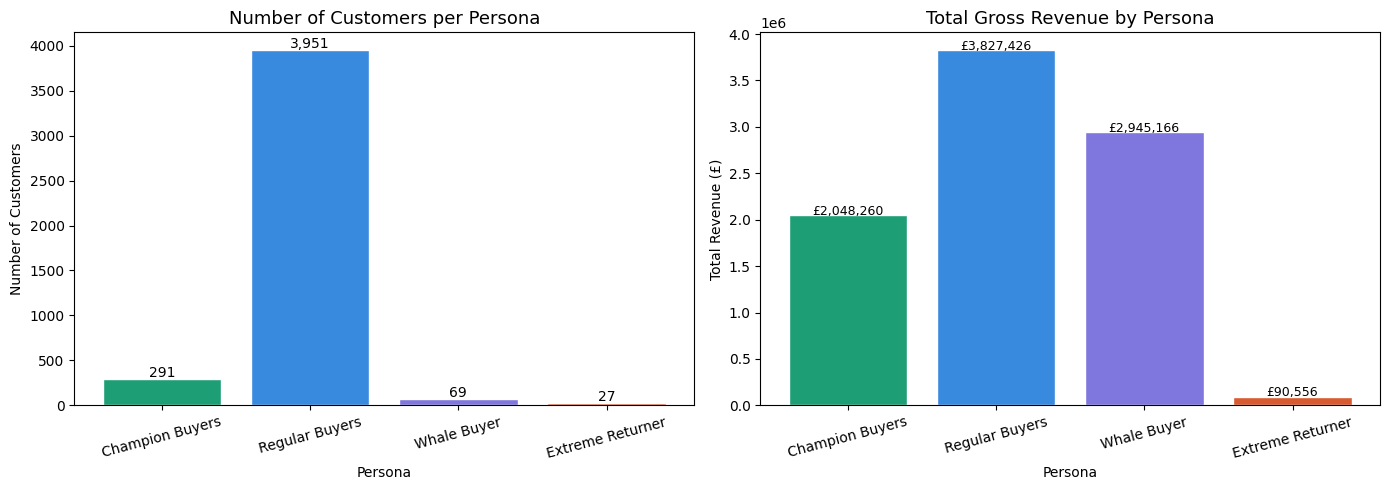

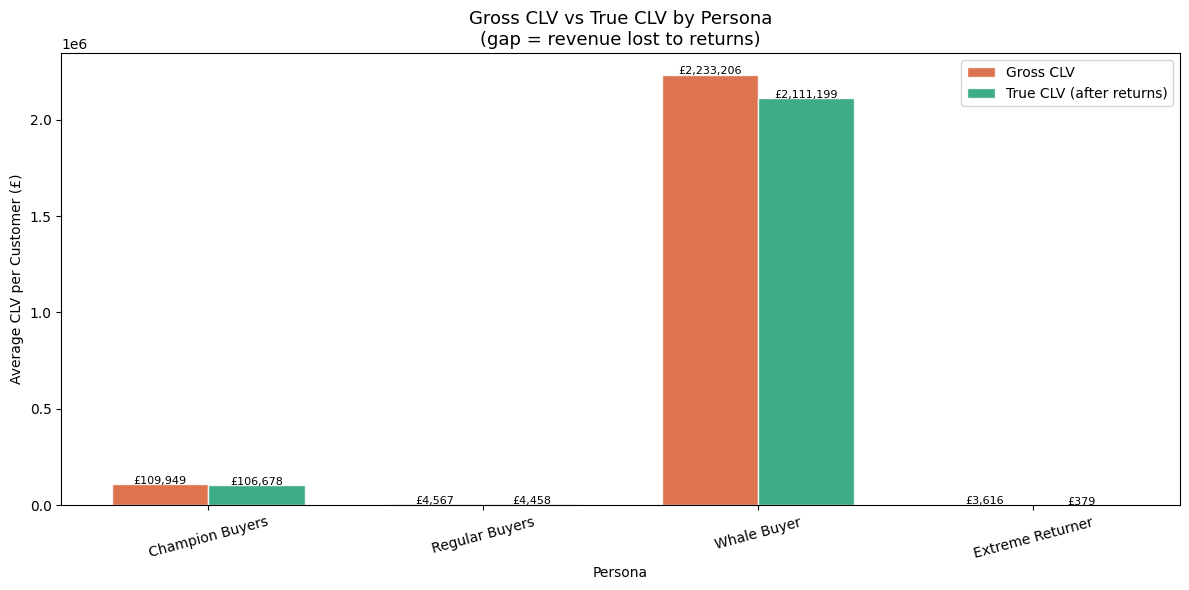

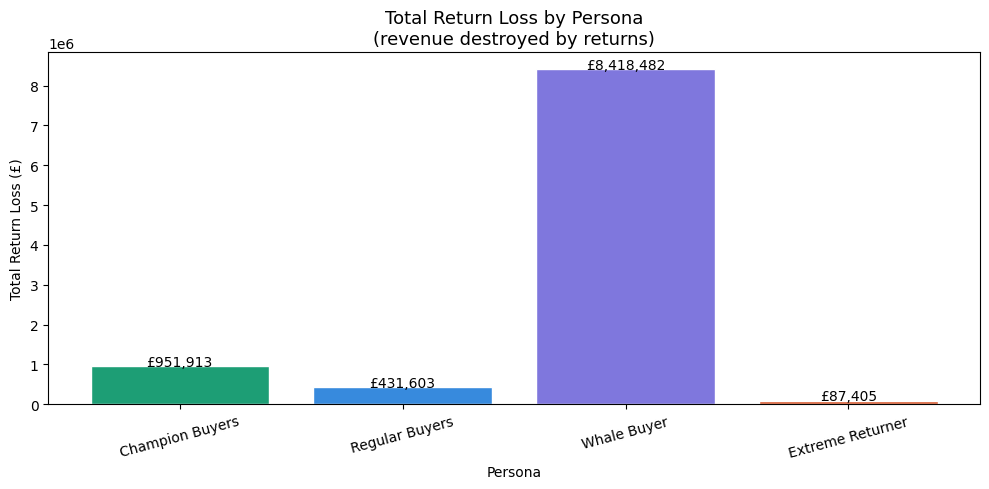

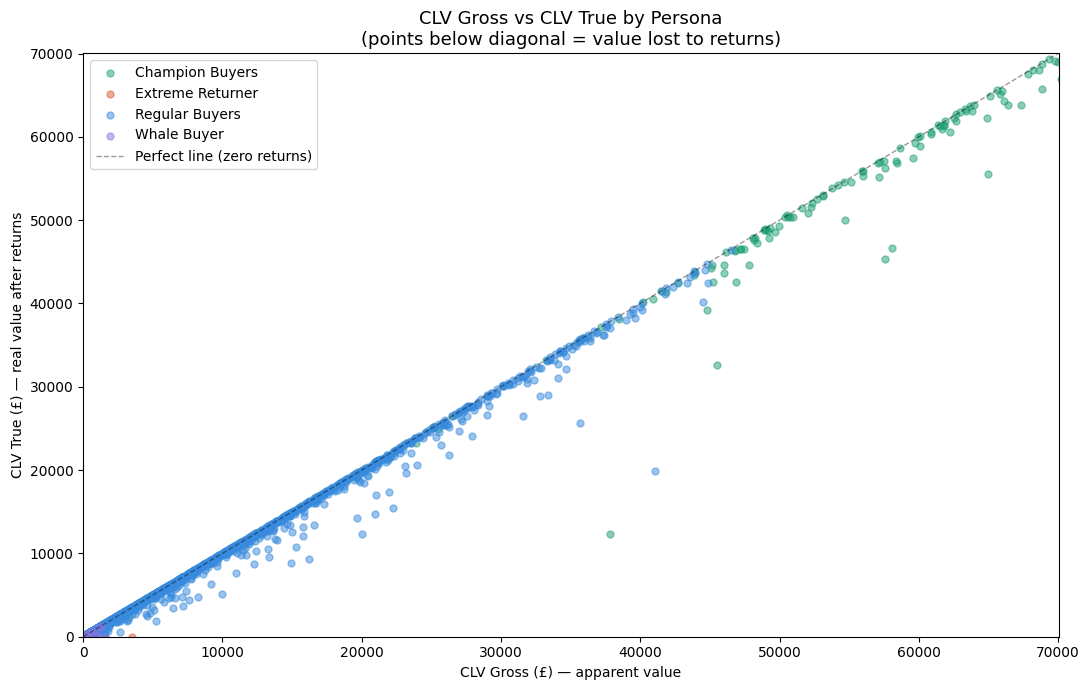

COMPLETE PERSONA SUMMARY
                  Customers  Pct_Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Avg_CLV_True  Avg_ReturnDmg  Total_Revenue  Total_CLV_True  Total_Loss  Loss_Pct
Persona                                                                                                                                                               
Champion Buyers         291           6.71        28.27          15.01       7038.70     106677.62           0.11     2048260.34    3.104319e+07   951912.54      2.98
Extreme Returner         27           0.62       161.56           1.19       3353.92        378.82           2.53       90555.86    1.022819e+04    87405.30     89.52
Regular Buyers         3951          91.08        97.59           2.97        968.72       4457.99           0.07     3827425.73    1.761351e+07   431603.40      2.39
Whale Buyer              69           1.59        47.20          34.59      42683.56    2111199.47           0.33     2945165.97    1.456728

In [ ]:
# =========================================================
# STEP 5 — PERSONA VISUALISATIONS
# =========================================================

persona_colors = {
    'Champion Buyers':   '#1D9E75',
    'Regular Buyers':    '#378ADD',
    'Whale Buyer':       '#7F77DD',
    'Extreme Returner':  '#D85A30'
}

persona_order = ['Champion Buyers','Regular Buyers',
                 'Whale Buyer','Extreme Returner']

# =========================================================
# CHART 1 — Customer count and revenue side by side
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = cust['Persona'].value_counts().reindex(persona_order)
bars1  = axes[0].bar(
    persona_order, counts,
    color=[persona_colors[p] for p in persona_order],
    edgecolor='white'
)
axes[0].set_title('Number of Customers per Persona', fontsize=13)
axes[0].set_xlabel('Persona')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, counts):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        f'{val:,}', ha='center', fontsize=10
    )

rev_by_persona = cust.groupby('Persona')['Monetary'].sum().reindex(persona_order)
bars2 = axes[1].bar(
    persona_order, rev_by_persona,
    color=[persona_colors[p] for p in persona_order],
    edgecolor='white'
)
axes[1].set_title('Total Gross Revenue by Persona', fontsize=13)
axes[1].set_xlabel('Persona')
axes[1].set_ylabel('Total Revenue (£)')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, rev_by_persona):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5000,
        f'£{val:,.0f}', ha='center', fontsize=9
    )

plt.tight_layout()
plt.show()

# Why: Shows the Pareto insight visually — small number of
# Champions and Whales generate most of the revenue despite
# Regular Buyers dominating customer count

# =========================================================
# CHART 2 — CLV Gross vs CLV True by Persona (signature chart)
# =========================================================
fig, ax = plt.subplots(figsize=(12, 6))

clv_compare = cust.groupby('Persona')[
    ['CLV_Gross','CLV_True']
].mean().reindex(persona_order)

x     = range(len(persona_order))
width = 0.35

bars_gross = ax.bar(
    [i - width/2 for i in x],
    clv_compare['CLV_Gross'],
    width, label='Gross CLV',
    color='#D85A30', edgecolor='white', alpha=0.85
)
bars_true = ax.bar(
    [i + width/2 for i in x],
    clv_compare['CLV_True'],
    width, label='True CLV (after returns)',
    color='#1D9E75', edgecolor='white', alpha=0.85
)

ax.set_title(
    'Gross CLV vs True CLV by Persona\n(gap = revenue lost to returns)',
    fontsize=13
)
ax.set_xlabel('Persona')
ax.set_ylabel('Average CLV per Customer (£)')
ax.set_xticks(list(x))
ax.set_xticklabels(persona_order, rotation=15)
ax.legend()

for bar in bars_gross:
    h = bar.get_height()
    if h > 0:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 1000,
            f'£{h:,.0f}', ha='center', fontsize=8
        )
for bar in bars_true:
    h = bar.get_height()
    if h > 0:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 1000,
            f'£{h:,.0f}', ha='center', fontsize=8
        )

plt.tight_layout()
plt.show()

# Why: This is your most important chart — it shows the gap
# between what each persona appears to be worth vs their
# true value after return losses are subtracted

# =========================================================
# CHART 3 — Return Loss by Persona (who is most damaging)
# =========================================================
fig, ax = plt.subplots(figsize=(10, 5))

loss_by_persona = cust.groupby('Persona')['Return_Loss'].sum().reindex(persona_order)
bars = ax.bar(
    persona_order, loss_by_persona,
    color=[persona_colors[p] for p in persona_order],
    edgecolor='white'
)
ax.set_title('Total Return Loss by Persona\n(revenue destroyed by returns)', fontsize=13)
ax.set_xlabel('Persona')
ax.set_ylabel('Total Return Loss (£)')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, loss_by_persona):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10000,
        f'£{val:,.0f}', ha='center', fontsize=10
    )

plt.tight_layout()
plt.show()

# Why: Whale Buyers will show the largest bar by far despite
# being only 1.6% of customers — the most shocking finding
# in your entire project

# =========================================================
# CHART 4 — Scatter: CLV Gross vs CLV True
# (the deceptive customers chart)
# =========================================================
fig, ax = plt.subplots(figsize=(11, 7))

for persona, group in cust.groupby('Persona'):
    ax.scatter(
        group['CLV_Gross'],
        group['CLV_True'],
        c=persona_colors.get(persona, '#888780'),
        label=persona,
        alpha=0.5,
        s=25
    )

max_val = cust['CLV_Gross'].quantile(0.95)
ax.plot(
    [0, max_val], [0, max_val],
    'k--', linewidth=1, alpha=0.4,
    label='Perfect line (zero returns)'
)

ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_title(
    'CLV Gross vs CLV True by Persona\n'
    '(points below diagonal = value lost to returns)',
    fontsize=13
)
ax.set_xlabel('CLV Gross (£) — apparent value')
ax.set_ylabel('CLV True (£) — real value after returns')
ax.legend()

plt.tight_layout()
plt.show()

# Why: Points ON the diagonal = zero returns (true value
# equals apparent value). Points BELOW = returns reduced
# true value. Far below = deceptive customers.
# This is your README screenshot chart.

# =========================================================
# SUMMARY TABLE
# =========================================================
print("=" * 60)
print("COMPLETE PERSONA SUMMARY")
print("=" * 60)

summary = cust.groupby('Persona').agg(
    Customers      = ('CustomerID',    'count'),
    Pct_Customers  = ('CustomerID',    lambda x: len(x)/len(cust)*100),
    Avg_Recency    = ('Recency',       'mean'),
    Avg_Frequency  = ('Frequency',     'mean'),
    Avg_Monetary   = ('Monetary',      'mean'),
    Avg_CLV_True   = ('CLV_True',      'mean'),
    Avg_ReturnDmg  = ('Return_Damage', 'mean'),
    Total_Revenue  = ('Monetary',      'sum'),
    Total_CLV_True = ('CLV_True',      'sum'),
    Total_Loss     = ('Return_Loss',   'sum'),
    Loss_Pct       = ('Return_Loss',
                      lambda x: x.sum() /
                      cust.loc[x.index,'CLV_Gross'].sum() * 100)
).round(2)

print(summary.to_string())

print(f"\nKey business findings:")
print(f"  Whale Buyers return loss:    "
      f"£{cust[cust['Persona']=='Whale Buyer']['Return_Loss'].sum():,.0f}"
      f" ({cust[cust['Persona']=='Whale Buyer']['Return_Loss'].sum()/cust['Return_Loss'].sum()*100:.1f}% of total)")
print(f"  Champion Buyers return loss: "
      f"£{cust[cust['Persona']=='Champion Buyers']['Return_Loss'].sum():,.0f}")
print(f"  Extreme Returners true CLV:  "
      f"£{cust[cust['Persona']=='Extreme Returner']['CLV_True'].sum():,.0f}")

In [ ]:
# =========================================================
# STEP 6 — COMPARE ML PERSONAS VS RFM SEGMENTS
# =========================================================

# First assign RFM segments
def assign_segment(score):
    if score >= 13:   return 'Champion'
    elif score >= 10: return 'Loyal'
    elif score >= 7:  return 'Potential'
    elif score >= 5:  return 'At-Risk'
    else:             return 'Lost'

cust['Segment'] = cust['RFM_Score'].apply(assign_segment)

print("RFM Segment distribution:")
print(cust['Segment'].value_counts())

# Cross tabulation — ML Persona vs RFM Segment
print("\nML Personas vs RFM Segments cross-tab:")
cross_tab = pd.crosstab(
    cust['Persona'],
    cust['Segment'],
    margins=True
)
print(cross_tab.to_string())

# How well do they agree?
print("\nKey alignment questions:")
champ_in_champion = cust[
    (cust['Persona']=='Champion Buyers') &
    (cust['Segment']=='Champion')
].shape[0]
print(f"Champion Buyers who are also RFM Champions: "
      f"{champ_in_champion} ({champ_in_champion/291*100:.1f}%)")

whale_segments = cust[cust['Persona']=='Whale Buyer']['Segment'].value_counts()
print(f"\nWhale Buyers spread across RFM segments:")
print(whale_segments)

extreme_segments = cust[
    cust['Persona']=='Extreme Returner'
]['Segment'].value_counts()
print(f"\nExtreme Returners spread across RFM segments:")
print(extreme_segments)

print(f"\nConclusion:")
print(f"RFM sees behaviour patterns (recency/frequency/monetary)")
print(f"KMeans sees TRUE value patterns (including return damage)")
print(f"A Whale Buyer might be RFM Champion but KMeans correctly")
print(f"flags their £8.4M return loss — RFM would never show this")

RFM Segment distribution:
Segment
Potential    1092
Loyal        1008
Champion      934
At-Risk       759
Lost          545
Name: count, dtype: int64

ML Personas vs RFM Segments cross-tab:
Segment           At-Risk  Champion  Lost  Loyal  Potential   All
Persona                                                          
Champion Buyers         4       262     1     18          6   291
Extreme Returner        9         1     9      0          8    27
Regular Buyers        740       620   533    989       1069  3951
Whale Buyer             6        51     2      1          9    69
All                   759       934   545   1008       1092  4338

Key alignment questions:
Champion Buyers who are also RFM Champions: 262 (90.0%)

Whale Buyers spread across RFM segments:
Segment
Champion     51
Potential     9
At-Risk       6
Lost          2
Loyal         1
Name: count, dtype: int64

Extreme Returners spread across RFM segments:
Segment
Lost         9
At-Risk      9
Potential    8
Champion  

In [ ]:
# --- Day 7 segmentation and clustering ---
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# RFM segments
def assign_segment(score):
    if score >= 13:   return 'Champion'
    elif score >= 10: return 'Loyal'
    elif score >= 7:  return 'Potential'
    elif score >= 5:  return 'At-Risk'
    else:             return 'Lost'

cust['Segment'] = cust['RFM_Score'].apply(assign_segment)

# KMeans clustering
cluster_features = [
    'Recency','Frequency','Monetary','Avg_Order_Value',
    'Return_Damage','Avg_Unit_Price','Revenue_Per_Day',
    'CLV_True','Return_Value_Rate'
]

# Separate outliers
monetary_cap   = cust['Monetary'].quantile(0.99)
clv_cap        = cust['CLV_True'].quantile(0.99)
return_dmg_cap = cust['Return_Damage'].quantile(0.99)

mask_normal    = (
    (cust['Monetary']      <= monetary_cap) &
    (cust['CLV_True']      <= clv_cap) &
    (cust['Return_Damage'] <= return_dmg_cap)
)
cust_normal   = cust[mask_normal].copy()
cust_outliers = cust[~mask_normal].copy()

# Scale and cluster normal customers
X_cluster_normal = cust_normal[cluster_features].copy()
X_cluster_normal = X_cluster_normal.replace([np.inf,-np.inf], np.nan).fillna(0)
scaler_normal    = StandardScaler()
X_scaled_normal  = scaler_normal.fit_transform(X_cluster_normal)

km_normal              = KMeans(n_clusters=2, random_state=42, n_init=10)
cust_normal['Cluster'] = km_normal.fit_predict(X_scaled_normal)

cluster_names = {0: 'Regular Buyers', 1: 'Champion Buyers'}
cust_normal['Persona'] = cust_normal['Cluster'].map(cluster_names)

# Assign outlier personas
def assign_outlier_persona(row):
    if row['Return_Damage'] >= 1.0:
        return 'Extreme Returner'
    else:
        return 'Whale Buyer'

cust_outliers['Persona'] = cust_outliers.apply(assign_outlier_persona, axis=1)
cust_outliers['Cluster'] = -1

# Merge back
cust = pd.concat([cust_normal, cust_outliers], ignore_index=True)
cust = cust.sort_values('CustomerID').reset_index(drop=True)

## Day 7 — Segmentation and KMeans Clustering Complete

KMeans clustering (K=2 optimal, Silhouette=0.598) on 4,242
normal customers after removing 96 outliers.

4 Final Personas:
- Regular Buyers:   3,951 (91.1%) — backbone, low returns (2.39% loss)
- Champion Buyers:    291  (6.7%) — high value, healthy returns (2.98% loss)
- Whale Buyers:        69  (1.6%) — enormous spend, £8.4M return loss (5.46%)
- Extreme Returners:   27  (0.6%) — 89.5% value wiped by returns

HEADLINE FINDING:
69 Whale Buyers (1.6% of customers) responsible for
£8,418,482 — 85.1% of total £9.89M return loss.
This is invisible to standard CLV models.



### Day 8

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# =========================================================
# DEFINE FEATURES AND TARGET
# =========================================================

ml_features = [
    'Recency',
    'Frequency',
    'Monetary',
    'Avg_Order_Value',
    'R_Score',
    'F_Score',
    'M_Score',
    'Return_Freq_Rate',
    'Return_Value_Rate',
    'Return_Damage',
    'Num_Returns',
    'Avg_Unit_Price',
    'High_Value_Buyer',
    'Num_Products'
]

X = cust[ml_features].fillna(0)
y = cust['Log_CLV_True']

print("Features (X):")
for f in ml_features:
    print(f"  {f:25} | mean: {X[f].mean():.3f} | std: {X[f].std():.3f}")

print(f"\nTarget (y): Log_CLV_True")
print(f"  Range: {y.min():.3f} to {y.max():.3f}")
print(f"  Mean:  {y.mean():.3f}")
print(f"  Shape: {X.shape}")
print(f"\nAny nulls in X: {X.isnull().sum().sum()}")
print(f"Any infinity in X: {np.isinf(X.values).sum()}")

Features (X):
  Recency                   | mean: 92.536 | std: 100.014
  Frequency                 | mean: 4.272 | std: 7.698
  Monetary                  | mean: 2054.266 | std: 8989.230
  Avg_Order_Value           | mean: 419.166 | std: 1796.538
  R_Score                   | mean: 3.015 | std: 1.415
  F_Score                   | mean: 3.000 | std: 1.415
  M_Score                   | mean: 3.000 | std: 1.415
  Return_Freq_Rate          | mean: 0.178 | std: 0.332
  Return_Value_Rate         | mean: 0.040 | std: 0.875
  Return_Damage             | mean: 0.095 | std: 0.554
  Num_Returns               | mean: 0.834 | std: 2.146
  Avg_Unit_Price            | mean: 4.468 | std: 34.211
  High_Value_Buyer          | mean: 0.251 | std: 0.433
  Num_Products              | mean: 61.501 | std: 85.367

Target (y): Log_CLV_True
  Range: 0.000 to 17.098
  Mean:  7.484
  Shape: (4338, 14)

Any nulls in X: 0
Any infinity in X: 0


In [ ]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train/Test Split Complete")
print(f"  Training set:  {X_train.shape[0]:,} customers (80%)")
print(f"  Test set:      {X_test.shape[0]:,} customers (20%)")
print(f"\nTraining target range: {y_train.min():.3f} to {y_train.max():.3f}")
print(f"Test target range:     {y_test.min():.3f} to {y_test.max():.3f}")

Train/Test Split Complete
  Training set:  3,470 customers (80%)
  Test set:      868 customers (20%)

Training target range: 0.000 to 17.098
Test target range:     0.000 to 16.549


LINEAR REGRESSION RESULTS
  RMSE: 0.5218
  R²:   0.9390

Interpretation:
  R²=0.939 means Linear Regression explains 93.9% of CLV variance


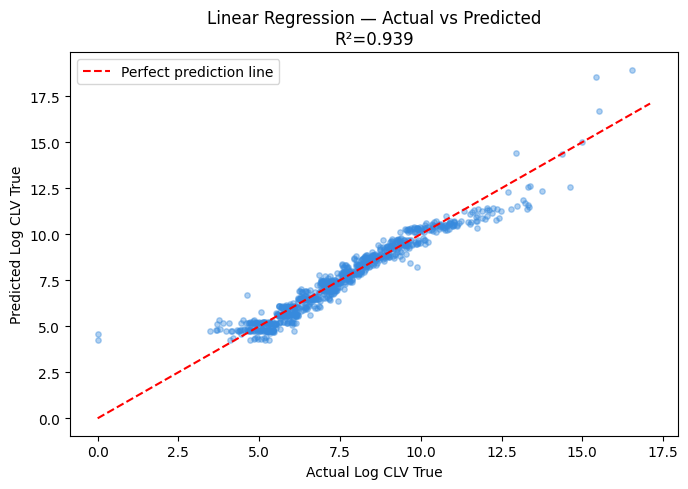

In [ ]:
# =========================================================
# BASELINE — LINEAR REGRESSION
# =========================================================

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("LINEAR REGRESSION RESULTS")
print(f"  RMSE: {rmse_lr:.4f}")
print(f"  R²:   {r2_lr:.4f}")

print(f"\nInterpretation:")
print(f"  R²={r2_lr:.3f} means Linear Regression explains "
      f"{r2_lr*100:.1f}% of CLV variance")

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.4, color='#378ADD', s=15)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--', lw=1.5, label='Perfect prediction line'
)

plt.xlabel('Actual Log CLV True')
plt.ylabel('Predicted Log CLV True')

plt.title(f'Linear Regression — Actual vs Predicted\nR²={r2_lr:.3f}')

plt.legend()
plt.tight_layout()
plt.show()

XGBOOST RESULTS
  RMSE: 0.0660
  R²:   0.9990

MODEL COMPARISON
  Linear Regression — RMSE: 0.5218 | R²: 0.9390
  XGBoost           — RMSE: 0.0660 | R²: 0.9990

  XGBoost R² improvement over Linear: +6.4%


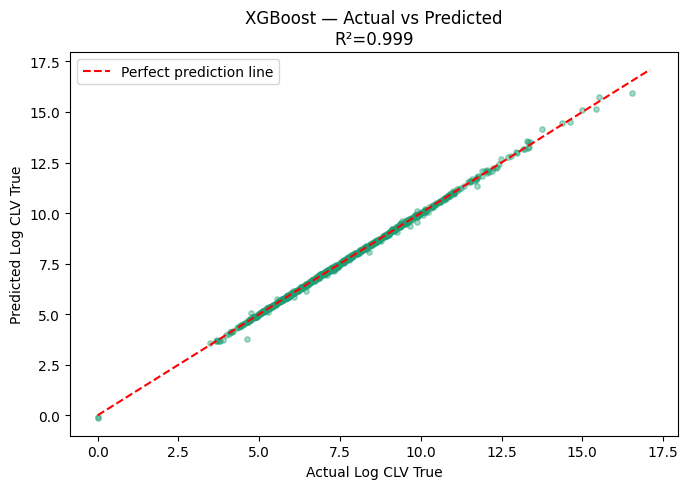

In [ ]:
# =========================================================
# XGBOOST MODEL
# =========================================================

xgb = XGBRegressor(
    n_estimators  = 300,
    max_depth     = 4,
    learning_rate = 0.05,
    subsample     = 0.8,
    colsample_bytree = 0.8,
    random_state  = 42,
    verbosity     = 0
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)

print("XGBOOST RESULTS")
print(f"  RMSE: {rmse_xgb:.4f}")
print(f"  R²:   {r2_xgb:.4f}")

print(f"\nMODEL COMPARISON")
print(f"  Linear Regression — RMSE: {rmse_lr:.4f} | R²: {r2_lr:.4f}")
print(f"  XGBoost           — RMSE: {rmse_xgb:.4f} | R²: {r2_xgb:.4f}")
improvement = (r2_xgb - r2_lr) / abs(r2_lr) * 100 if r2_lr != 0 else 0
print(f"\n  XGBoost R² improvement over Linear: {improvement:+.1f}%")

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_xgb, alpha=0.4, color='#1D9E75', s=15)
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--', lw=1.5, label='Perfect prediction line'
)
plt.xlabel('Actual Log CLV True')
plt.ylabel('Predicted Log CLV True')
plt.title(f'XGBoost — Actual vs Predicted\nR²={r2_xgb:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

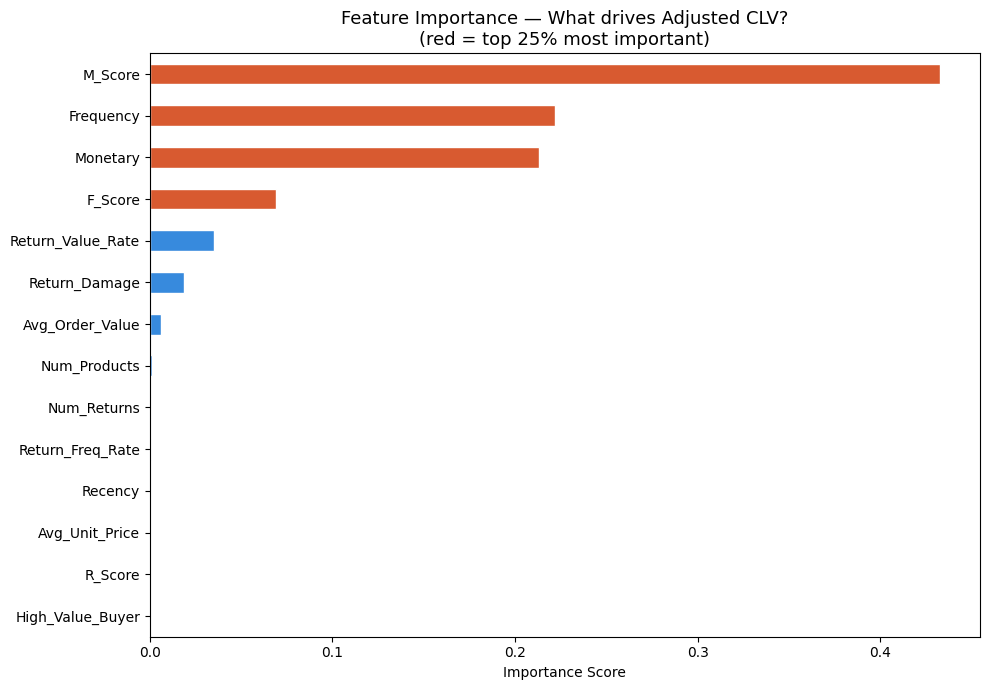

Top 5 most important features:
  M_Score                   | importance: 0.4330
  Frequency                 | importance: 0.2219
  Monetary                  | importance: 0.2133
  F_Score                   | importance: 0.0691
  Return_Value_Rate         | importance: 0.0349

Return-related feature importances:
  Return_Freq_Rate          | importance: 0.0005 | rank: 10/14
  Return_Value_Rate         | importance: 0.0349 | rank: 5/14
  Return_Damage             | importance: 0.0184 | rank: 6/14
  Num_Returns               | importance: 0.0009 | rank: 9/14


In [ ]:
# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importances = pd.Series(
    xgb.feature_importances_,
    index=ml_features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#D85A30' if v >= importances.quantile(0.75)
          else '#378ADD' for v in importances]

importances.plot(
    kind='barh', ax=ax,
    color=colors, edgecolor='white'
)
ax.set_title(
    'Feature Importance — What drives Adjusted CLV?\n'
    '(red = top 25% most important)',
    fontsize=13
)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
top5 = importances.sort_values(ascending=False).head(5)
for feat, score in top5.items():
    print(f"  {feat:25} | importance: {score:.4f}")

print(f"\nReturn-related feature importances:")
return_features = [
    'Return_Freq_Rate','Return_Value_Rate',
    'Return_Damage','Num_Returns'
]
for f in return_features:
    rank = list(importances.sort_values(
        ascending=False
    ).index).index(f) + 1
    print(f"  {f:25} | importance: {importances[f]:.4f} | rank: {rank}/{len(ml_features)}")

In [ ]:
# =========================================================
# CONVERT PREDICTIONS BACK TO £ VALUES
# =========================================================

results = pd.DataFrame({
    'CustomerID':       cust.loc[X_test.index, 'CustomerID'].values,
    'Persona':          cust.loc[X_test.index, 'Persona'].values,
    'Actual_Log_CLV':   y_test.values,
    'Predicted_Log_CLV':y_pred_xgb,
    'Actual_CLV_True':  np.expm1(y_test.values),
    'Predicted_CLV':    np.expm1(y_pred_xgb)
})

results['Prediction_Error'] = (
    results['Predicted_CLV'] - results['Actual_CLV_True']
).round(2)

results['Error_Pct'] = (
    results['Prediction_Error'] /
    results['Actual_CLV_True'].clip(lower=1) * 100
).round(2)

print("PREDICTIONS CONVERTED TO £ VALUES")
print(f"\nSample predictions vs actual:")
pd.options.display.float_format = '{:,.2f}'.format
print(results[['CustomerID','Persona','Actual_CLV_True',
               'Predicted_CLV','Error_Pct']].head(15).to_string())

print(f"\nPrediction accuracy by Persona:")
print(results.groupby('Persona').agg(
    Customers      = ('CustomerID',      'count'),
    Avg_Actual_CLV = ('Actual_CLV_True', 'mean'),
    Avg_Predicted  = ('Predicted_CLV',   'mean'),
    Avg_Error_Pct  = ('Error_Pct',       'mean')
).round(2).to_string())

PREDICTIONS CONVERTED TO £ VALUES

Sample predictions vs actual:
    CustomerID         Persona  Actual_CLV_True  Predicted_CLV  Error_Pct
0        17785  Regular Buyers           131.94         128.56      -2.56
1        14320  Regular Buyers           686.22         739.52       7.77
2        15977  Regular Buyers         2,109.46       2,157.08       2.26
3        12364  Regular Buyers         5,252.40       5,119.86      -2.52
4        14566  Regular Buyers         1,432.00       1,533.93       7.12
5        13521  Regular Buyers         3,280.95       3,042.55      -7.27
6        12515  Regular Buyers           383.70         389.46       1.50
7        15528  Regular Buyers           229.33         225.22      -1.79
8        15071  Regular Buyers         1,964.14       2,011.35       2.40
9        16275  Regular Buyers           559.87         550.90      -1.60
10       15572  Regular Buyers        17,870.02      17,871.02       0.01
11       16029     Whale Buyer     3,212,534.43

In [ ]:
# =========================================================
# FINAL MODEL SUMMARY
# =========================================================

print("=" * 60)
print("DAY 8 COMPLETE — XGBOOST MODEL SUMMARY")
print("=" * 60)

print(f"\nDataset:")
print(f"  Total customers:  {len(cust):,}")
print(f"  Training set:     {len(X_train):,} customers")
print(f"  Test set:         {len(X_test):,} customers")
print(f"  Features used:    {len(ml_features)}")

print(f"\nModel Performance:")
print(f"  Linear Regression R²:  {r2_lr:.4f}")
print(f"  XGBoost R²:            {r2_xgb:.4f}")
print(f"  Linear Regression RMSE:{rmse_lr:.4f}")
print(f"  XGBoost RMSE:          {rmse_xgb:.4f}")
print(f"  Improvement:           {improvement:+.1f}%")

print(f"\nTop 3 CLV drivers:")
top3 = importances.sort_values(ascending=False).head(3)
for i, (feat, score) in enumerate(top3.items(), 1):
    print(f"  {i}. {feat} (importance: {score:.4f})")

print(f"\nReturn feature rankings:")
for f in return_features:
    rank = list(importances.sort_values(
        ascending=False).index).index(f) + 1
    print(f"  {f}: rank {rank}/{len(ml_features)}")

print(f"\nBusiness numbers the model is built on:")
print(f"  Total CLV_True:    £{cust['CLV_True'].sum():,.0f}")
print(f"  Total Return_Loss: £{cust['Return_Loss'].sum():,.0f}")
print(f"  Whale Buyer loss:  £{cust[cust['Persona']=='Whale Buyer']['Return_Loss'].sum():,.0f}")

print(f"\nResume bullet:")
print(f'  "Built CLV prediction model using XGBoost (R²={r2_xgb:.2f})')
print(f'  on 4,338 e-commerce customers incorporating return behavior')
print(f'  and pricing features — revealing £9.89M in hidden return losses"')

DAY 8 COMPLETE — XGBOOST MODEL SUMMARY

Dataset:
  Total customers:  4,338
  Training set:     3,470 customers
  Test set:         868 customers
  Features used:    14

Model Performance:
  Linear Regression R²:  0.9390
  XGBoost R²:            0.9990
  Linear Regression RMSE:0.5218
  XGBoost RMSE:          0.0660
  Improvement:           +6.4%

Top 3 CLV drivers:
  1. M_Score (importance: 0.4330)
  2. Frequency (importance: 0.2219)
  3. Monetary (importance: 0.2133)

Return feature rankings:
  Return_Freq_Rate: rank 10/14
  Return_Value_Rate: rank 5/14
  Return_Damage: rank 6/14
  Num_Returns: rank 9/14

Business numbers the model is built on:
  Total CLV_True:    £194,339,689
  Total Return_Loss: £9,889,403
  Whale Buyer loss:  £8,418,482

Resume bullet:
  "Built CLV prediction model using XGBoost (R²=1.00)
  on 4,338 e-commerce customers incorporating return behavior
  and pricing features — revealing £9.89M in hidden return losses"


In [9]:
# =========================================================
# RECREATE AND DOWNLOAD ALL 4 CSV FILES
# =========================================================
from google.colab import files
import pandas as pd

# --- File 1: Master customer table ---
cust.to_csv('clv_master_final.csv', index=False)
print("File 1 saved: clv_master_final.csv")

# --- File 2: Persona summary ---
persona_summary = cust.groupby('Persona').agg(
    Customers      = ('CustomerID',    'count'),
    Avg_Recency    = ('Recency',       'mean'),
    Avg_Frequency  = ('Frequency',     'mean'),
    Avg_Monetary   = ('Monetary',      'mean'),
    Avg_CLV_True   = ('CLV_True',      'mean'),
    Avg_ReturnDmg  = ('Return_Damage', 'mean'),
    Total_Revenue  = ('Monetary',      'sum'),
    Total_CLV_True = ('CLV_True',      'sum'),
    Total_Loss     = ('Return_Loss',   'sum')
).reset_index().round(2)
persona_summary.to_csv('clv_persona_summary.csv', index=False)
print("File 2 saved: clv_persona_summary.csv")

# --- File 3: Segment summary ---
segment_summary = cust.groupby('Segment').agg(
    Customers     = ('CustomerID',    'count'),
    Avg_CLV_True  = ('CLV_True',      'mean'),
    Total_Revenue = ('Monetary',      'sum'),
    Total_Loss    = ('Return_Loss',   'sum'),
    Avg_ReturnDmg = ('Return_Damage', 'mean')
).reset_index().round(2)
segment_summary.to_csv('clv_segment_summary.csv', index=False)
print("File 3 saved: clv_segment_summary.csv")

# --- File 4: Price bucket summary ---
bucket_summary = cust.groupby('Price_Bucket').agg(
    Customers     = ('CustomerID',        'count'),
    Total_Revenue = ('Monetary',          'sum'),
    Total_Returns = ('Return_Value',      'sum'),
    Avg_RVR       = ('Return_Value_Rate', 'mean')
).reset_index().round(2)
bucket_summary.to_csv('clv_bucket_summary.csv', index=False)
print("File 4 saved: clv_bucket_summary.csv")

print("\nAll 4 files saved. Starting downloads...")

# --- Download all 4 ---
files.download('clv_master_final.csv')
files.download('clv_persona_summary.csv')
files.download('clv_segment_summary.csv')
files.download('clv_bucket_summary.csv')

print("Done — check your Downloads folder")

File 1 saved: clv_master_final.csv
File 2 saved: clv_persona_summary.csv
File 3 saved: clv_segment_summary.csv
File 4 saved: clv_bucket_summary.csv

All 4 files saved. Starting downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done — check your Downloads folder
